In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os

folders = [
    "Share_Market_ML_Project/data",
    "Share_Market_ML_Project/notebooks",
    "Share_Market_ML_Project/models",
    "Share_Market_ML_Project/dashboard",
    "Share_Market_ML_Project/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

In [ ]:
!find Share_Market_ML_Project -maxdepth 2 -type d

In [ ]:
!pip install -q yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

ticker = "^NSEI"

df = yf.download(
    ticker,
    period="10y",
    interval="1d",
    auto_adjust=False
)

print("Data downloaded successfully!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

df.head()

In [ ]:
file_path = "Share_Market_ML_Project/data/NIFTY50_10Y.csv"

df.to_csv(file_path)

print("Saved successfully!")
print(file_path)

In [ ]:
df.info()

In [ ]:
# Flatten the column names
df.columns = df.columns.get_level_values(0)

# Reset index
df = df.reset_index()

# Remove unnecessary column
df = df.drop(columns=["Adj Close"])

# Check the cleaned data
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

In [ ]:
file_path = "Share_Market_ML_Project/data/NIFTY50_clean.csv"

df.to_csv(file_path, index=False)

print("Clean NIFTY 50 data saved successfully!")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("NIFTY 50 Closing Price - 10 Year Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

# Price Change
df["Price_Change"] = df["Close"].diff()

# 20-day Simple Moving Average
df["SMA_20"] = df["Close"].rolling(window=20).mean()

# 50-day Simple Moving Average
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# Volume Change
df["Volume_Change"] = df["Volume"].pct_change()

# Remove rows created by rolling calculations
df = df.dropna().reset_index(drop=True)

print("Feature engineering completed!")
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

In [ ]:
def classify_trend(return_value):
    if return_value > 0.005:
        return "UP"
    elif return_value < -0.005:
        return "DOWN"
    else:
        return "SIDEWAYS"


df["Trend"] = df["Daily_Return"].apply(classify_trend)

print("Trend labeling completed!")

print("\nTrend distribution:")
print(df["Trend"].value_counts())

print("\nSample data:")
display(df[["Date", "Close", "Daily_Return", "SMA_20", "SMA_50", "Trend"]].head(10))

In [ ]:
# Tomorrow's return
df["Future_Return"] = df["Close"].shift(-1) / df["Close"] - 1


# Create tomorrow's trend
def classify_future_trend(return_value):
    if return_value > 0.005:
        return "UP"
    elif return_value < -0.005:
        return "DOWN"
    else:
        return "SIDEWAYS"


df["Future_Trend"] = df["Future_Return"].apply(classify_future_trend)

# Last row has no future data
df = df.dropna(subset=["Future_Return"]).reset_index(drop=True)

print("Future trend labeling completed!")

print("\nFuture Trend Distribution:")
print(df["Future_Trend"].value_counts())

print("\nSample:")
display(
    df[
        [
            "Date",
            "Close",
            "Daily_Return",
            "SMA_20",
            "SMA_50",
            "Volume_Change",
            "Future_Return",
            "Future_Trend"
        ]
    ].head(10)
)

In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change"
]

target = "Future_Trend"

X = df[features]
y = df[target]

# Chronological split: 80% old data for training, 20% recent data for testing
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Date"].iloc[split_index], "to", df["Date"].iloc[-1])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Model")
print("=" * 40)
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Accuracy (%): {knn_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

In [ ]:
import numpy as np

# Check infinity values
print("Infinity values:")
print(np.isinf(X_train).sum())

# Replace infinity with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Check missing values
print("\nMissing values after replacing infinity:")
print("Train:")
print(X_train.isnull().sum())

print("\nTest:")
print(X_test.isnull().sum())

In [ ]:
# Remove rows containing NaN
train_mask = X_train.notna().all(axis=1)
test_mask = X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print("Cleaned training samples:", len(X_train))
print("Cleaned testing samples:", len(X_test))

In [ ]:
print("Remaining infinity in train:",
      np.isinf(X_train).sum().sum())

print("Remaining infinity in test:",
      np.isinf(X_test).sum().sum())

print("Remaining NaN in train:",
      X_train.isna().sum().sum())

print("Remaining NaN in test:",
      X_test.isna().sum().sum())

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Model")
print("=" * 40)
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Accuracy (%): {knn_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create CART / Decision Tree model
cart_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train
cart_model.fit(X_train, y_train)

# Predict
y_pred_cart = cart_model.predict(X_test)

# Accuracy
cart_accuracy = accuracy_score(y_test, y_pred_cart)

print("CART / Decision Tree Model")
print("=" * 40)
print(f"Accuracy: {cart_accuracy:.4f}")
print(f"Accuracy (%): {cart_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cart))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cart))

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Naïve Bayes model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naïve Bayes Model")
print("=" * 40)
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Accuracy (%): {nb_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Ensemble Model")
print("=" * 40)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Accuracy (%): {rf_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

model_results = pd.DataFrame({
    "Model": [
        "KNN",
        "CART",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_cart),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Macro Precision": [
        precision_score(y_test, y_pred_knn, average="macro"),
        precision_score(y_test, y_pred_cart, average="macro"),
        precision_score(y_test, y_pred_nb, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro")
    ],
    "Macro Recall": [
        recall_score(y_test, y_pred_knn, average="macro"),
        recall_score(y_test, y_pred_cart, average="macro"),
        recall_score(y_test, y_pred_nb, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro")
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_knn, average="macro"),
        f1_score(y_test, y_pred_cart, average="macro"),
        f1_score(y_test, y_pred_nb, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
})

display(model_results.round(4))

In [ ]:
model_results.to_csv(
    "Share_Market_ML_Project/results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "KNN": (knn_model, y_pred_knn),
    "CART": (cart_model, y_pred_cart),
    "Naive Bayes": (nb_model, y_pred_nb),
    "Random Forest": (rf_model, y_pred_rf)
}

for name, (_, predictions) in models.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        cmap="Blues"
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("NIFTY 50 Closing Price - 10 Year Trend")
plt.xlabel("Year")
plt.ylabel("Closing Price")

ax = plt.gca()

# Show every year
ax.xaxis.set_major_locator(mdates.YearLocator())

# Show only year: 2017, 2018, ... 2026
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("NIFTY 50 Closing Price - 10 Year Trend")
plt.xlabel("Year")
plt.ylabel("Closing Price")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Stop x-axis at the last actual data date
ax.set_xlim(df["Date"].min(), df["Date"].max())

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

class_counts = y.value_counts()

print("Future Trend Distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Future Trend Class Distribution")
plt.xlabel("Trend")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.grid(axis="y")
plt.show()

In [ ]:
class_percentage = y.value_counts(normalize=True) * 100

print("Future Trend Percentage:")
print(class_percentage.round(2))

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": cart_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("CART Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
# Technical Indicators

# RSI
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))


# MACD
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26


# Volatility
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()


# Remove missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().reset_index(drop=True)

print("Technical indicators added successfully!")

display(
    df[
        [
            "Date",
            "Close",
            "RSI_14",
            "MACD",
            "Volatility_20"
        ]
    ].tail()
)

In [ ]:
features_v2 = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

X = df[features_v2]
y = df["Future_Trend"]

In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df[features_v2 + ["Future_Trend"]].isna().sum())

print("\nTarget distribution:")
print(df["Future_Trend"].value_counts())

In [ ]:
from sklearn.model_selection import train_test_split

features_v2 = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

X = df[features_v2]
y = df["Future_Trend"]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train_v2 = X.iloc[:split_index].copy()
X_test_v2 = X.iloc[split_index:].copy()

y_train_v2 = y.iloc[:split_index].copy()
y_test_v2 = y.iloc[split_index:].copy()

print("Training samples:", len(X_train_v2))
print("Testing samples:", len(X_test_v2))

print("\nTraining period:")
print(df["Date"].iloc[:split_index].min(), "to",
      df["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Date"].iloc[split_index], "to",
      df["Date"].iloc[-1])

In [ ]:
from sklearn.model_selection import train_test_split

features_v2 = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

X = df[features_v2]
y = df["Future_Trend"]

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train_v2 = X.iloc[:split_index].copy()
X_test_v2 = X.iloc[split_index:].copy()

y_train_v2 = y.iloc[:split_index].copy()
y_test_v2 = y.iloc[split_index:].copy()

print("Training samples:", len(X_train_v2))
print("Testing samples:", len(X_test_v2))

print("\nTraining period:")
print(df["Date"].iloc[:split_index].min(), "to",
      df["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Date"].iloc[split_index], "to",
      df["Date"].iloc[-1])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler_v2 = StandardScaler()

X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test_v2)

knn_v2 = KNeighborsClassifier(n_neighbors=5)

knn_v2.fit(X_train_scaled_v2, y_train_v2)

y_pred_knn_v2 = knn_v2.predict(X_test_scaled_v2)

print("KNN Accuracy:",
      accuracy_score(y_test_v2, y_pred_knn_v2))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

cart_v2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

cart_v2.fit(X_train_v2, y_train_v2)

y_pred_cart_v2 = cart_v2.predict(X_test_v2)

print("CART Accuracy:",
      accuracy_score(y_test_v2, y_pred_cart_v2))

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_v2 = GaussianNB()

nb_v2.fit(X_train_v2, y_train_v2)

y_pred_nb_v2 = nb_v2.predict(X_test_v2)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test_v2, y_pred_nb_v2))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(X_train_v2, y_train_v2)

y_pred_rf_v2 = rf_v2.predict(X_test_v2)

print("Random Forest Accuracy:",
      accuracy_score(y_test_v2, y_pred_rf_v2))

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_results_v2 = pd.DataFrame({
    "Model": [
        "KNN",
        "CART",
        "Naive Bayes",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test_v2, y_pred_knn_v2),
        accuracy_score(y_test_v2, y_pred_cart_v2),
        accuracy_score(y_test_v2, y_pred_nb_v2),
        accuracy_score(y_test_v2, y_pred_rf_v2)
    ],

    "Macro Precision": [
        precision_score(y_test_v2, y_pred_knn_v2, average="macro"),
        precision_score(y_test_v2, y_pred_cart_v2, average="macro"),
        precision_score(y_test_v2, y_pred_nb_v2, average="macro"),
        precision_score(y_test_v2, y_pred_rf_v2, average="macro")
    ],

    "Macro Recall": [
        recall_score(y_test_v2, y_pred_knn_v2, average="macro"),
        recall_score(y_test_v2, y_pred_cart_v2, average="macro"),
        recall_score(y_test_v2, y_pred_nb_v2, average="macro"),
        recall_score(y_test_v2, y_pred_rf_v2, average="macro")
    ],

    "Macro F1": [
        f1_score(y_test_v2, y_pred_knn_v2, average="macro"),
        f1_score(y_test_v2, y_pred_cart_v2, average="macro"),
        f1_score(y_test_v2, y_pred_nb_v2, average="macro"),
        f1_score(y_test_v2, y_pred_rf_v2, average="macro")
    ]
})

display(model_results_v2.round(4))

In [ ]:
model_results_v2.to_csv(
    "Share_Market_ML_Project/results/model_comparison_v2.csv",
    index=False
)

print("Updated model comparison saved successfully!")

In [ ]:
display(model_results_v2.round(4))

In [ ]:
thresholds = [0.003, 0.005, 0.007, 0.010]

threshold_results = []

for threshold in thresholds:

    temp_trend = np.where(
        df["Future_Return"] > threshold,
        "UP",
        np.where(
            df["Future_Return"] < -threshold,
            "DOWN",
            "SIDEWAYS"
        )
    )

    counts = pd.Series(temp_trend).value_counts()

    threshold_results.append({
        "Threshold": f"±{threshold*100:.1f}%",
        "DOWN": counts.get("DOWN", 0),
        "SIDEWAYS": counts.get("SIDEWAYS", 0),
        "UP": counts.get("UP", 0),
        "Total": len(temp_trend)
    })

threshold_distribution = pd.DataFrame(threshold_results)

display(threshold_distribution)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

thresholds = [0.003, 0.005, 0.007, 0.010]

threshold_model_results = []

for threshold in thresholds:

    # Create target
    y_threshold = np.where(
        df["Future_Return"] > threshold,
        "UP",
        np.where(
            df["Future_Return"] < -threshold,
            "DOWN",
            "SIDEWAYS"
        )
    )

    y_threshold = pd.Series(
        y_threshold,
        index=df.index
    )

    # Same chronological 80/20 split
    split_index = int(len(df) * 0.80)

    X_train_t = df[features_v2].iloc[:split_index]
    X_test_t = df[features_v2].iloc[split_index:]

    y_train_t = y_threshold.iloc[:split_index]
    y_test_t = y_threshold.iloc[split_index:]

    # CART
    model = DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    )

    model.fit(X_train_t, y_train_t)

    prediction = model.predict(X_test_t)

    threshold_model_results.append({
        "Threshold": f"±{threshold*100:.1f}%",
        "Accuracy": accuracy_score(y_test_t, prediction),
        "Macro F1": f1_score(
            y_test_t,
            prediction,
            average="macro"
        )
    })

threshold_model_results = pd.DataFrame(
    threshold_model_results
)

display(threshold_model_results.round(4))

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

threshold = 0.007

y_threshold = np.where(
    df["Future_Return"] > threshold,
    "UP",
    np.where(
        df["Future_Return"] < -threshold,
        "DOWN",
        "SIDEWAYS"
    )
)

y_threshold = pd.Series(
    y_threshold,
    index=df.index
)

split_index = int(len(df) * 0.80)

X_train_t = df[features_v2].iloc[:split_index]
X_test_t = df[features_v2].iloc[split_index:]

y_train_t = y_threshold.iloc[:split_index]
y_test_t = y_threshold.iloc[split_index:]

cart_07 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

cart_07.fit(X_train_t, y_train_t)

y_pred_cart_07 = cart_07.predict(X_test_t)

print("Accuracy:",
      accuracy_score(y_test_t, y_pred_cart_07))

print("Macro F1:",
      f1_score(
          y_test_t,
          y_pred_cart_07,
          average="macro"
      ))

ConfusionMatrixDisplay.from_predictions(
    y_test_t,
    y_pred_cart_07
)

plt.title("CART - ±0.7% Threshold")
plt.show()

In [ ]:
cart_balanced = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

cart_balanced.fit(X_train_v2, y_train_v2)

y_pred_cart_balanced = cart_balanced.predict(X_test_v2)

print("Balanced CART Accuracy:",
      accuracy_score(y_test_v2, y_pred_cart_balanced))

print("Balanced CART Macro Precision:",
      precision_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

print("Balanced CART Macro Recall:",
      recall_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

print("Balanced CART Macro F1:",
      f1_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_v2,
    y_pred_cart_balanced
)

plt.title("Balanced CART - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Balanced CART Results")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test_v2, y_pred_cart_balanced))

print("Macro Precision:",
      precision_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          y_test_v2,
          y_pred_cart_balanced,
          average="macro"
      ))

In [ ]:
# Last available feature row: 23 Sep 2026
latest_data = df.iloc[[-1]][features]

# Original CART model prediction
latest_prediction = cart_model.predict(latest_data)[0]

print("Latest Date:", df["Date"].iloc[-1])
print("Predicted Trend for Next Trading Day:", latest_prediction)

In [ ]:
probabilities = cart_model.predict_proba(latest_data)[0]

probability_table = pd.DataFrame({
    "Trend": cart_model.classes_,
    "Probability": probabilities
})

display(probability_table)

In [ ]:
previous_close = 23446.800781
current_close = 23063.10

actual_return = (current_close / previous_close) - 1

if actual_return > 0.005:
    actual_trend = "UP"
elif actual_return < -0.005:
    actual_trend = "DOWN"
else:
    actual_trend = "SIDEWAYS"

print("Actual Return:", round(actual_return * 100, 2), "%")
print("Actual Trend:", actual_trend)

In [ ]:
print("Predicted Trend:", latest_prediction)
print("Actual Trend:", actual_trend)

if latest_prediction == actual_trend:
    print("Prediction Result: Correct")
else:
    print("Prediction Result: Incorrect")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Align test dates and future returns with the original CART predictions
backtest_df = pd.DataFrame({
    "Date": df.loc[y_test.index, "Date"].values,
    "Actual_Return": df.loc[y_test.index, "Future_Return"].values,
    "Actual_Trend": y_test.values,
    "Predicted_Trend": y_pred_cart
})

# Strategy:
# UP -> hold NIFTY for next trading day
# DOWN / SIDEWAYS -> stay in cash
backtest_df["Strategy_Return"] = np.where(
    backtest_df["Predicted_Trend"] == "UP",
    backtest_df["Actual_Return"],
    0
)

# Cumulative returns
backtest_df["Strategy_Equity"] = (
    1 + backtest_df["Strategy_Return"]
).cumprod()

backtest_df["Buy_Hold_Equity"] = (
    1 + backtest_df["Actual_Return"]
).cumprod()

# Maximum drawdown
strategy_peak = backtest_df["Strategy_Equity"].cummax()

backtest_df["Strategy_Drawdown"] = (
    backtest_df["Strategy_Equity"] / strategy_peak - 1
)

max_drawdown = backtest_df["Strategy_Drawdown"].min()

# Summary
strategy_return = backtest_df["Strategy_Equity"].iloc[-1] - 1
buy_hold_return = backtest_df["Buy_Hold_Equity"].iloc[-1] - 1

up_signals = (
    backtest_df["Predicted_Trend"] == "UP"
).sum()

print("===== BACKTEST RESULTS =====")
print("Test Period:",
      backtest_df["Date"].min(),
      "to",
      backtest_df["Date"].max())

print("Strategy Return:",
      round(strategy_return * 100, 2), "%")

print("Buy & Hold Return:",
      round(buy_hold_return * 100, 2), "%")

print("Maximum Drawdown:",
      round(max_drawdown * 100, 2), "%")

print("UP Signals:",
      up_signals)

print("Total Test Days:",
      len(backtest_df))

In [ ]:
df.loc[y_test.index, "Date"]

In [ ]:
# Backtest using the current v2 CART model

backtest_df = pd.DataFrame({
    "Date": df["Date"].iloc[split_index:].values,
    "Actual_Return": df["Future_Return"].iloc[split_index:].values,
    "Actual_Trend": y_test_v2.values,
    "Predicted_Trend": y_pred_cart_v2
})

print("Backtest rows:", len(backtest_df))
display(backtest_df.head())

In [ ]:
# UP prediction -> hold NIFTY
# DOWN / SIDEWAYS -> stay in cash

backtest_df["Strategy_Return"] = np.where(
    backtest_df["Predicted_Trend"] == "UP",
    backtest_df["Actual_Return"],
    0
)

# Cumulative equity
backtest_df["Strategy_Equity"] = (
    1 + backtest_df["Strategy_Return"]
).cumprod()

backtest_df["Buy_Hold_Equity"] = (
    1 + backtest_df["Actual_Return"]
).cumprod()

# Maximum Drawdown
strategy_peak = backtest_df["Strategy_Equity"].cummax()

backtest_df["Strategy_Drawdown"] = (
    backtest_df["Strategy_Equity"] / strategy_peak - 1
)

strategy_return = backtest_df["Strategy_Equity"].iloc[-1] - 1
buy_hold_return = backtest_df["Buy_Hold_Equity"].iloc[-1] - 1
max_drawdown = backtest_df["Strategy_Drawdown"].min()

up_signals = (
    backtest_df["Predicted_Trend"] == "UP"
).sum()

print("===== BACKTEST RESULTS =====")
print("Test Period:",
      backtest_df["Date"].min(),
      "to",
      backtest_df["Date"].max())

print("Strategy Return:",
      round(strategy_return * 100, 2), "%")

print("Buy & Hold Return:",
      round(buy_hold_return * 100, 2), "%")

print("Maximum Drawdown:",
      round(max_drawdown * 100, 2), "%")

print("UP Signals:", up_signals)
print("Total Test Days:", len(backtest_df))

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df["Date"],
    backtest_df["Strategy_Equity"],
    label="CART Strategy"
)

plt.plot(
    backtest_df["Date"],
    backtest_df["Buy_Hold_Equity"],
    label="Buy & Hold"
)

plt.title("CART Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("===== FINAL BACKTEST SUMMARY =====")

print("Strategy Return:",
      round(strategy_return * 100, 2), "%")

print("Buy & Hold Return:",
      round(buy_hold_return * 100, 2), "%")

print("Maximum Drawdown:",
      round(max_drawdown * 100, 2), "%")

print("UP Signals:",
      up_signals)

print("Total Test Days:",
      len(backtest_df))

In [ ]:
backtest_df.to_csv(
    "Share_Market_ML_Project/results/cart_v2_backtest.csv",
    index=False
)

print("Backtest results saved successfully!")

In [ ]:
import matplotlib.pyplot as plt

# Model comparison
model_names = ["KNN", "CART", "Naive Bayes", "Random Forest"]

accuracy_values = [
    knn_acc_v2,
    cart_acc_v2,
    nb_acc_v2,
    rf_acc_v2
]

plt.figure(figsize=(10, 6))

plt.bar(model_names, accuracy_values)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_results = pd.read_csv(
    "Share_Market_ML_Project/results/model_comparison_v2.csv"
)

display(model_results)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved V2 model results
model_results = pd.read_csv(
    "Share_Market_ML_Project/results/model_comparison_v2.csv"
)

print("Model Comparison V2")
display(model_results)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_results = pd.read_csv(
    "Share_Market_ML_Project/results/model_comparison_v2.csv"
)

plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

x = range(len(model_results))

plt.plot(x, model_results["Accuracy"], marker="o", label="Accuracy")
plt.plot(x, model_results["Macro Precision"], marker="o", label="Macro Precision")
plt.plot(x, model_results["Macro Recall"], marker="o", label="Macro Recall")
plt.plot(x, model_results["Macro F1"], marker="o", label="Macro F1")

plt.xticks(x, model_results["Model"])
plt.ylabel("Score")
plt.title("ML Model Performance Comparison")

plt.ylim(0, 0.6)
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# ==========================================
# CART V2 FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

feature_names = features_v2

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cart_model_v2.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("CART V2 Feature Importance:")
display(importance_df)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# TRAIN CART V2 MODEL
# ==========================================

cart_model_v2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

cart_model_v2.fit(X_train_v2, y_train_v2)

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_names = features_v2

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cart_model_v2.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("CART V2 Feature Importance:")
display(importance_df)

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CART V2 Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# CART V2 predictions
cm_cart_v2 = confusion_matrix(
    y_test_v2,
    y_pred_cart_v2,
    labels=["DOWN", "SIDEWAYS", "UP"]
)

print("CART V2 Confusion Matrix:")
print(cm_cart_v2)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cart_v2,
    display_labels=["DOWN", "SIDEWAYS", "UP"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

plt.title("CART V2 Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import os

dashboard_path = "Share_Market_ML_Project/dashboard/app.py"

os.makedirs(
    "Share_Market_ML_Project/dashboard",
    exist_ok=True
)

print("Dashboard folder ready!")
print(dashboard_path)

In [ ]:
%%writefile Share_Market_ML_Project/dashboard/app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="Share Market ML Dashboard",
    page_icon="📈",
    layout="wide"
)

# ==========================================
# PATHS
# ==========================================

BASE_PATH = "Share_Market_ML_Project"

DATA_PATH = os.path.join(
    BASE_PATH, "data", "NIFTY50_clean.csv"
)

MODEL_PATH = os.path.join(
    BASE_PATH, "results", "model_comparison_v2.csv"
)

BACKTEST_PATH = os.path.join(
    BASE_PATH, "results", "cart_v2_backtest.csv"
)

# ==========================================
# TITLE
# ==========================================

st.title("📈 Share Market Trend Analysis")
st.subheader("Machine Learning Based NIFTY 50 Analysis")

st.markdown(
    "Educational machine learning dashboard for historical "
    "NIFTY 50 trend analysis and model evaluation."
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])

model_results = pd.read_csv(MODEL_PATH)
backtest_df = pd.read_csv(BACKTEST_PATH)
backtest_df["Date"] = pd.to_datetime(backtest_df["Date"])

# ==========================================
# MARKET SUMMARY
# ==========================================

latest = df.iloc[-1]

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Latest Close",
        f"{latest['Close']:,.2f}"
    )

with col2:
    st.metric(
        "SMA 20",
        f"{latest['SMA_20']:,.2f}"
        if "SMA_20" in df.columns else "N/A"
    )

with col3:
    st.metric(
        "RSI 14",
        f"{latest['RSI_14']:.2f}"
        if "RSI_14" in df.columns else "N/A"
    )

with col4:
    st.metric(
        "Volatility 20",
        f"{latest['Volatility_20']:.4f}"
        if "Volatility_20" in df.columns else "N/A"
    )

# ==========================================
# NIFTY PRICE CHART
# ==========================================

st.header("📊 NIFTY 50 Price Trend")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["Date"],
    df["Close"]
)

ax.set_xlabel("Date")
ax.set_ylabel("NIFTY 50 Close")
ax.set_title("NIFTY 50 Historical Closing Price")

ax.grid(True)

st.pyplot(fig)

# ==========================================
# MODEL PERFORMANCE
# ==========================================

st.header("🤖 Machine Learning Model Performance")

display_columns = [
    "Model",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

st.dataframe(
    model_results[display_columns],
    use_container_width=True
)

# ==========================================
# MODEL ACCURACY CHART
# ==========================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(axis="y")

st.pyplot(fig)

# ==========================================
# BACKTEST
# ==========================================

st.header("📈 CART Strategy Backtest")

strategy_return = (
    backtest_df["Strategy_Equity"].iloc[-1] - 1
)

buy_hold_return = (
    backtest_df["Buy_Hold_Equity"].iloc[-1] - 1
)

max_drawdown = (
    backtest_df["Strategy_Drawdown"].min()
)

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Strategy Return",
        f"{strategy_return * 100:.2f}%"
    )

with col2:
    st.metric(
        "Buy & Hold Return",
        f"{buy_hold_return * 100:.2f}%"
    )

with col3:
    st.metric(
        "Maximum Drawdown",
        f"{max_drawdown * 100:.2f}%"
    )

# ==========================================
# EQUITY CURVE
# ==========================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    backtest_df["Date"],
    backtest_df["Strategy_Equity"],
    label="CART Strategy"
)

ax.plot(
    backtest_df["Date"],
    backtest_df["Buy_Hold_Equity"],
    label="Buy & Hold"
)

ax.set_title("CART Strategy vs Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of ₹1")

ax.legend()
ax.grid(True)

st.pyplot(fig)

# ==========================================
# PROJECT SUMMARY
# ==========================================

st.header("📋 Project Summary")

st.write("""
This project analyzes historical NIFTY 50 data using machine learning.

The project includes data preprocessing, feature engineering,
supervised learning models, model performance evaluation,
feature importance analysis and historical backtesting.

The models evaluated are KNN, CART, Naive Bayes and Random Forest.
""")

st.warning(
    "This dashboard is for educational and analytical purposes. "
    "Historical model performance does not guarantee future market results."
)

st.caption(
    "Share Market Trend Analysis & ML-Based Trading Decision Support System"
)

In [ ]:
!pip install -q streamlit

In [ ]:
!streamlit run Share_Market_ML_Project/dashboard/app.py &>/content/streamlit.log &

In [ ]:
!sleep 3
!cat /content/streamlit.log

In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

In [ ]:
!tail -30 /content/streamlit.log

In [ ]:
import requests

r = requests.get("http://localhost:8501")
print("Status:", r.status_code)

In [ ]:
!tail -50 /content/streamlit.log

In [ ]:
!pkill -f "streamlit run" || true

In [ ]:
!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
import time
time.sleep(3)

!tail -20 /content/streamlit.log

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

In [ ]:
# Save current V2 dataframe
df.to_csv(
    "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv",
    index=False
)

print("V2 dataset saved successfully!")
print(df.columns.tolist())

In [ ]:
DATA_PATH = os.path.join(
    BASE_PATH, "data", "NIFTY50_clean_v2.csv"
)

In [ ]:
import os

BASE_PATH = "Share_Market_ML_Project"

DATA_PATH = os.path.join(
    BASE_PATH,
    "data",
    "NIFTY50_clean_v2.csv"
)

print("DATA_PATH:")
print(DATA_PATH)

print("File exists:", os.path.exists(DATA_PATH))

In [ ]:
DATA_PATH = os.path.join(
    BASE_PATH, "data", "NIFTY50_clean.csv"
)

In [ ]:
DATA_PATH = os.path.join(
    BASE_PATH, "data", "NIFTY50_clean_v2.csv"
)

In [ ]:
!pkill -f "streamlit run" || true

In [ ]:
!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
# Update dashboard to use V2 dataset

app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

app_code = app_code.replace(
    'DATA_PATH = os.path.join(\n    BASE_PATH, "data", "NIFTY50_clean.csv"\n)',
    'DATA_PATH = os.path.join(\n    BASE_PATH, "data", "NIFTY50_clean_v2.csv"\n)'
)

with open(app_path, "w") as f:
    f.write(app_code)

print("Dashboard DATA_PATH updated to V2!")

In [ ]:
!grep -A3 "DATA_PATH" Share_Market_ML_Project/dashboard/app.py

In [ ]:
!pkill -f "streamlit run" || true

In [ ]:
!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
import time
time.sleep(3)

!tail -10 /content/streamlit.log

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

feature_section = '''
# ==============================
# Feature Importance
# ==============================

st.header("🔍 CART Feature Importance")

feature_names = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

feature_importance = [
    0.119653,
    0.018606,
    0.159580,
    0.003297,
    0.151693,
    0.154875,
    0.082209,
    0.310088
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
ax.set_xlabel("Importance")
ax.set_title("CART Feature Importance")
plt.tight_layout()

st.pyplot(fig)

# ==============================
# Confusion Matrix
# ==============================

st.header("🔲 CART Confusion Matrix")

confusion_matrix_data = np.array([
    [13, 77, 18],
    [14, 210, 29],
    [15, 77, 21]
])

labels = ["DOWN", "SIDEWAYS", "UP"]

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(confusion_matrix_data)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("CART Confusion Matrix")

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            confusion_matrix_data[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

st.pyplot(fig)
'''

# Add before Project Summary section
marker = 'st.header("📋 Project Summary")'

if marker in app_code:
    app_code = app_code.replace(
        marker,
        feature_section + "\n\n" + marker
    )
else:
    app_code += "\n\n" + feature_section

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ Feature Importance + Confusion Matrix added!")

In [ ]:
!grep -n "Feature Importance\|Confusion Matrix" Share_Market_ML_Project/dashboard/app.py

In [ ]:
!pkill -f "streamlit run" || true

!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

# Add NumPy import if it is missing
if "import numpy as np" not in app_code:
    app_code = app_code.replace(
        "import pandas as pd",
        "import pandas as pd\nimport numpy as np"
    )

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ NumPy import added!")

In [ ]:
!head -15 Share_Market_ML_Project/dashboard/app.py

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!pkill -f "streamlit run" || true

!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
%%writefile Share_Market_ML_Project/README.md

# Share Market Trend Analysis & ML-Based Trading Decision Support System

## 1. Project Overview

This project analyzes historical NIFTY 50 market data using machine learning techniques. The system performs data preprocessing, feature engineering, trend classification, model evaluation and historical backtesting.

The project also provides a Streamlit dashboard for visualizing market trends, model performance, feature importance and backtesting results.

## 2. Problem Statement

Predicting short-term stock market direction is challenging because market prices are affected by many factors and contain significant uncertainty.

This project studies whether machine learning models can classify the next trading day's NIFTY 50 movement into three categories:

- DOWN
- SIDEWAYS
- UP

## 3. Objectives

- Collect historical NIFTY 50 data.
- Clean and preprocess the dataset.
- Create useful technical features.
- Develop supervised machine learning models.
- Compare model performance.
- Analyze feature importance.
- Evaluate classification using a confusion matrix.
- Perform historical backtesting.
- Develop an interactive Streamlit dashboard.

## 4. Dataset

The project uses historical NIFTY 50 daily market data.

The dataset contains:

- Date
- Open
- High
- Low
- Close
- Volume

The project uses approximately 10 years of daily market data.

## 5. Data Preprocessing

The preprocessing steps include:

- Removing unnecessary columns.
- Flattening multi-level column names.
- Converting the dataset into a suitable tabular format.
- Handling missing values.
- Handling infinite values.
- Removing rows affected by rolling calculations.
- Maintaining chronological order for training and testing.

An 80:20 chronological split was used for training and testing.

## 6. Feature Engineering

The following features were created:

- Daily Return
- Price Change
- SMA 20
- SMA 50
- Volume Change
- RSI 14
- MACD
- Volatility 20

The target variable is Future Trend.

The next trading day's return is classified into:

- DOWN
- SIDEWAYS
- UP

## 7. Machine Learning Models

The following supervised learning algorithms were evaluated:

1. K-Nearest Neighbors (KNN)
2. CART / Decision Tree
3. Gaussian Naive Bayes
4. Random Forest

The models were trained using historical observations and evaluated on a chronological test dataset.

## 8. Model Performance

The V2 model results are:

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| KNN | 47.26% | 37.40% | 36.22% | 35.19% |
| CART | 51.48% | 39.84% | 37.88% | 36.20% |
| Naive Bayes | 51.90% | 35.07% | 35.05% | 29.35% |
| Random Forest | 51.69% | 26.33% | 33.75% | 26.83% |

Accuracy alone was not used to evaluate the models. Macro precision, macro recall and macro F1 were also considered because the target contains three classes.

## 9. Feature Importance

The CART model feature importance analysis produced the following values:

| Feature | Importance |
|---|---:|
| Volatility 20 | 0.310088 |
| SMA 20 | 0.159580 |
| RSI 14 | 0.154875 |
| Volume Change | 0.151693 |
| Daily Return | 0.119653 |
| MACD | 0.082209 |
| Price Change | 0.018606 |
| SMA 50 | 0.003297 |

These values represent the contribution of features within the trained CART model.

## 10. Confusion Matrix

The CART V2 confusion matrix is:

| Actual / Predicted | DOWN | SIDEWAYS | UP |
|---|---:|---:|---:|
| DOWN | 13 | 77 | 18 |
| SIDEWAYS | 14 | 210 | 29 |
| UP | 15 | 77 | 21 |

The model identifies SIDEWAYS observations more frequently than the directional classes.

Therefore, class-wise performance should be considered along with overall accuracy.

## 11. Backtesting

A simple historical backtest was performed using the CART model.

The strategy takes a position when the model predicts an UP trend and remains out of the position for other predictions.

Backtesting results:

- Strategy Return: -1.86%
- Buy & Hold Return: -5.62%
- Maximum Drawdown: -7.85%
- UP Signals: 68
- Total Test Days: 474

The backtest is historical and educational. It does not guarantee future market performance.

## 12. Streamlit Dashboard

An interactive Streamlit dashboard was developed to present the project results.

The dashboard contains:

- Latest NIFTY 50 price
- SMA 20
- RSI 14
- Volatility 20
- NIFTY 50 price trend
- Machine learning model comparison
- CART strategy backtesting
- CART feature importance
- CART confusion matrix
- Project summary

## 13. Results

The project demonstrates the complete machine learning workflow from data collection and preprocessing to model evaluation and historical backtesting.

The evaluated models showed moderate overall accuracy, while class-wise results indicated difficulty in correctly identifying UP and DOWN market movements.

The project also demonstrates how machine learning results can be integrated into an interactive analytical dashboard.

## 14. Limitations

- Historical market data cannot guarantee future results.
- The model does not consider news and fundamental information.
- Transaction costs, taxes and slippage are not included in the basic backtest.
- Market conditions can change over time.
- The classification model has difficulty identifying some directional movements.
- The project is intended for educational and analytical purposes.

## 15. Future Enhancements

Possible future improvements include:

- Adding more technical indicators.
- Testing additional machine learning algorithms.
- Hyperparameter tuning.
- Cross-validation suitable for time-series data.
- Including transaction costs and slippage.
- Adding fundamental and macroeconomic variables.
- Developing portfolio tracking.
- Adding real-time market data.
- Improving the dashboard with interactive filters.

## 16. Conclusion

This project presents a machine learning based approach for analyzing NIFTY 50 market trends.

The workflow includes data preprocessing, feature engineering, supervised machine learning, model evaluation, feature importance analysis, confusion matrix analysis and historical backtesting.

The Streamlit dashboard provides an interactive way to visualize the analysis and model results.

The system is designed as an educational and analytical decision-support project rather than a guaranteed trading prediction system.

In [ ]:
!ls -lh Share_Market_ML_Project/README.md

In [ ]:
app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

# Today's current NIFTY 50 value
app_code = app_code.replace(
    'latest_close = latest["Close"]',
    'latest_close = 23063.10'
)

# Add today's market change information if not already present
if "current_nifty_change" not in app_code:
    marker = 'latest_close = 23063.10'
    app_code = app_code.replace(
        marker,
        marker + '''
current_nifty_change = -383.70
current_nifty_change_pct = -1.64
'''
    )

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ Dashboard current NIFTY value updated to 23,063.10")

In [ ]:
!grep -n "latest_close\|current_nifty" Share_Market_ML_Project/dashboard/app.py

In [ ]:
!pkill -f "streamlit run" || true

!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
st.metric("Latest Close", f"{latest_close:,.2f}")

In [ ]:
app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

app_code = app_code.replace(
    'st.metric("Latest Close", f"{latest_close:,.2f}")',
    '''current_nifty = 23063.10
current_change = -383.70
current_change_pct = -1.64

st.metric(
    "Current NIFTY 50",
    f"{current_nifty:,.2f}",
    f"{current_change:,.2f} ({current_change_pct:.2f}%)"
)'''
)

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ app.py updated successfully")

In [ ]:
!pkill -f "streamlit run" || true

!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
import pandas as pd
import numpy as np

# Original cleaned data
clean_path = "Share_Market_ML_Project/data/NIFTY50_clean.csv"

# V2 output
v2_path = "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv"

df = pd.read_csv(clean_path)

# Date format
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# -----------------------------
# Feature Engineering
# -----------------------------

df["Daily_Return"] = df["Close"].pct_change()

df["Price_Change"] = df["Close"].diff()

df["SMA_20"] = df["Close"].rolling(20).mean()

df["SMA_50"] = df["Close"].rolling(50).mean()

df["Volume_Change"] = df["Volume"].pct_change()

# -----------------------------
# RSI 14
# -----------------------------

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))

# -----------------------------
# MACD
# -----------------------------

ema_12 = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = ema_12 - ema_26

# -----------------------------
# Volatility
# -----------------------------

df["Volatility_20"] = (
    df["Daily_Return"].rolling(20).std()
)

# -----------------------------
# Trend
# -----------------------------

def classify_trend(return_value):
    if pd.isna(return_value):
        return np.nan
    elif return_value > 0.005:
        return "UP"
    elif return_value < -0.005:
        return "DOWN"
    else:
        return "SIDEWAYS"

df["Trend"] = df["Daily_Return"].apply(classify_trend)

# -----------------------------
# Future Return
# -----------------------------

df["Future_Return"] = (
    df["Close"].shift(-1) / df["Close"] - 1
)

df["Future_Trend"] = df["Future_Return"].apply(
    classify_trend
)

# Replace infinity
df = df.replace([np.inf, -np.inf], np.nan)

# Remove rows where technical indicators cannot be calculated
df = df.dropna(
    subset=[
        "Daily_Return",
        "Price_Change",
        "SMA_20",
        "SMA_50",
        "RSI_14",
        "MACD",
        "Volatility_20"
    ]
).reset_index(drop=True)

# Save V2
df.to_csv(v2_path, index=False)

print("✅ NIFTY50_clean_v2.csv updated successfully")
print("Rows:", len(df))
print()
print(df.tail(3))

In [ ]:
df_v2 = pd.read_csv(
    "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv"
)

print(df_v2.tail(5))
print("\nLast Date:", df_v2["Date"].iloc[-1])
print("Last Close:", df_v2["Close"].iloc[-1])

In [ ]:
df.loc[df["Date"] == "2026-09-24", "Volume"] = np.nan
df.loc[df["Date"] == "2026-09-24", "Volume_Change"] = np.nan

df.to_csv(
    "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv",
    index=False
)

print("✅ Volume corrected")

In [ ]:
app_path = "Share_Market_ML_Project/dashboard/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

# V2 CSV path
app_code = app_code.replace(
    'NIFTY50_clean.csv',
    'NIFTY50_clean_v2.csv'
)

# Replace Latest Close metric with Current NIFTY metric
old_metric = 'st.metric("Latest Close", f"{latest_close:,.2f}")'

new_metric = '''current_nifty = latest["Close"]

# Previous trading day close
previous_close = df["Close"].iloc[-2]

current_change = current_nifty - previous_close
current_change_pct = (current_change / previous_close) * 100

st.metric(
    "Current NIFTY 50",
    f"{current_nifty:,.2f}",
    f"{current_change:,.2f} ({current_change_pct:.2f}%)"
)'''

app_code = app_code.replace(old_metric, new_metric)

with open(app_path, "w") as f:
    f.write(app_code)

print("✅ Dashboard updated successfully")
print("✅ Data source: NIFTY50_clean_v2.csv")
print("✅ Current value will come automatically from CSV")

In [ ]:
!grep -n "DATA_PATH\|Current NIFTY\|latest\\[\"Close\"\\]" Share_Market_ML_Project/dashboard/app.py

In [ ]:
!pkill -f "streamlit run" || true

!streamlit run Share_Market_ML_Project/dashboard/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

In [ ]:
import pandas as pd
import numpy as np

RAW = "Share_Market_ML_Project/data/NIFTY50_10Y.csv"
CLEAN = "Share_Market_ML_Project/data/NIFTY50_clean.csv"
V2 = "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv"

# Original raw data
raw = pd.read_csv(RAW)

print("Raw shape:", raw.shape)
print(raw.tail())

In [ ]:
import pandas as pd
import numpy as np

RAW = "Share_Market_ML_Project/data/NIFTY50_10Y.csv"

# Read raw data
raw = pd.read_csv(RAW)

# Rename Price column to Date
raw = raw.rename(columns={"Price": "Date"})

# Convert Date
raw["Date"] = pd.to_datetime(raw["Date"])

# Remove duplicate dates
raw = raw.drop_duplicates(subset="Date", keep="last")

# Sort chronologically
raw = raw.sort_values("Date").reset_index(drop=True)

# Remove 24-Sep intraday/current row
raw = raw[raw["Date"] < "2026-09-24"].copy()

# Remove unnecessary adjusted close
if "Adj Close" in raw.columns:
    raw = raw.drop(columns=["Adj Close"])

# Save clean historical dataset
CLEAN = "Share_Market_ML_Project/data/NIFTY50_clean.csv"
raw.to_csv(CLEAN, index=False)

print("✅ Clean historical dataset created")
print("Shape:", raw.shape)
print()
print(raw.tail())
print()
print("Last Date:", raw["Date"].iloc[-1])
print("Last Close:", raw["Close"].iloc[-1])

In [ ]:
import pandas as pd
import numpy as np

RAW = "Share_Market_ML_Project/data/NIFTY50_10Y.csv"

# Read CSV
raw = pd.read_csv(RAW)

print("Original shape:", raw.shape)
print("Original columns:")
print(raw.columns.tolist())
print()
print("First 5 rows:")
display(raw.head())

In [ ]:
!pip install -q yfinance

import yfinance as yf
import pandas as pd

ticker = "^NSEI"

fresh = yf.download(
    ticker,
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

print("Shape:", fresh.shape)
print("Columns:", fresh.columns)
print()
display(fresh.tail())

In [ ]:
import yfinance as yf
import pandas as pd
import os

ticker = "^NSEI"

# Fresh NIFTY 50 data
fresh = yf.download(
    ticker,
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex
if isinstance(fresh.columns, pd.MultiIndex):
    fresh.columns = fresh.columns.get_level_values(0)

# Convert index to Date column
fresh = fresh.reset_index()

# Remove incomplete/current 24-Sep candle
fresh["Date"] = pd.to_datetime(fresh["Date"])
fresh = fresh[fresh["Date"] < "2026-09-24"].copy()

# Remove Adj Close
if "Adj Close" in fresh.columns:
    fresh = fresh.drop(columns=["Adj Close"])

# Remove duplicates and sort
fresh = fresh.drop_duplicates(subset="Date")
fresh = fresh.sort_values("Date").reset_index(drop=True)

# Save as NEW raw file
FRESH_RAW = "Share_Market_ML_Project/data/NIFTY50_raw_fresh.csv"
fresh.to_csv(FRESH_RAW, index=False)

print("✅ Fresh NIFTY 50 raw data saved")
print("Shape:", fresh.shape)
print()
print(fresh.tail())
print()
print("First Date:", fresh["Date"].iloc[0])
print("Last Date :", fresh["Date"].iloc[-1])
print("Last Close:", fresh["Close"].iloc[-1])

In [ ]:
import pandas as pd
import numpy as np

FRESH_RAW = "Share_Market_ML_Project/data/NIFTY50_raw_fresh.csv"
CLEAN = "Share_Market_ML_Project/data/NIFTY50_clean.csv"
V2 = "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv"

# =========================
# 1. Read fresh raw data
# =========================
df = pd.read_csv(FRESH_RAW)

# Date
df["Date"] = pd.to_datetime(df["Date"])

# Remove unnecessary columns if present
for col in ["Adj Close", "Price"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Keep required OHLCV columns
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

# Sort and remove duplicates
df = df.drop_duplicates(subset="Date")
df = df.sort_values("Date").reset_index(drop=True)

# Save clean historical data
df.to_csv(CLEAN, index=False)

print("✅ CLEAN CSV created")
print("Shape:", df.shape)
print()
display(df.tail())

In [ ]:
import pandas as pd
import numpy as np

CLEAN = "Share_Market_ML_Project/data/NIFTY50_clean.csv"
V2 = "Share_Market_ML_Project/data/NIFTY50_clean_v2.csv"

# =========================
# 1. Load clean data
# =========================
df = pd.read_csv(CLEAN)

df["Date"] = pd.to_datetime(df["Date"])

# =========================
# 2. Basic features
# =========================
df["Daily_Return"] = df["Close"].pct_change()

df["Price_Change"] = df["Close"].diff()

df["SMA_20"] = df["Close"].rolling(window=20).mean()

df["SMA_50"] = df["Close"].rolling(window=50).mean()

df["Volume_Change"] = df["Volume"].pct_change()

# =========================
# 3. RSI 14
# =========================
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))

# =========================
# 4. MACD
# =========================
ema_12 = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = ema_12 - ema_26

# =========================
# 5. Volatility 20
# =========================
df["Volatility_20"] = (
    df["Daily_Return"].rolling(window=20).std()
)

# =========================
# 6. Future Return
# =========================
df["Future_Return"] = (
    df["Close"].shift(-1) / df["Close"] - 1
)

# =========================
# 7. Future Trend
# =========================
def classify_future_trend(return_value):

    if return_value > 0.005:
        return "UP"

    elif return_value < -0.005:
        return "DOWN"

    else:
        return "SIDEWAYS"


df["Future_Trend"] = df["Future_Return"].apply(
    classify_future_trend
)

# =========================
# 8. Clean invalid values
# =========================
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna().reset_index(drop=True)

# =========================
# 9. Save V2 dataset
# =========================
df.to_csv(V2, index=False)

# =========================
# 10. Verification
# =========================
print("✅ V2 dataset created")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFuture Trend Distribution:")
print(df["Future_Trend"].value_counts())

print("\nLast 5 rows:")
display(df.tail())

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Fetch Latest NIFTY 50 Data from Yahoo Finance
print("📥 Fetching latest NIFTY 50 market data...")
nifty = yf.Ticker("^NSEI")
df_raw = nifty.history(period="10y")

# Reset Index & Format
df_raw.reset_index(inplace=True)
df_raw['Date'] = pd.to_datetime(df_raw['Date']).dt.date

# Select required OHLCV columns
df = df_raw[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].round(2)

print(f"✅ Raw Data Fetched! Shape: {df.shape}")
print(f"🗓️ Latest Date Available: {df['Date'].iloc[-1]}")
print(f"📈 Latest Close Price: ₹{df['Close'].iloc[-1]:,.2f}")

# 2. Feature Engineering Pipeline
print("\n⚙️ Processing V2 Features...")
df['Daily_Return'] = df['Close'].pct_change()
df['Price_Change'] = df['Close'] - df['Close'].shift(1)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['Volume_Change'] = df['Volume'].pct_change()

# RSI Calculation (14 Days)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# MACD Calculation
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26

# Volatility (20 Days)
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()

# Target Variable Formulation (Future Trend)
df['Future_Return'] = df['Daily_Return'].shift(-1)

def categorize_trend(ret):
    if pd.isna(ret):
        return np.nan
    elif ret < -0.0030:
        return 'DOWN'
    elif ret > 0.0030:
        return 'UP'
    else:
        return 'SIDEWAYS'

df['Future_Trend'] = df['Future_Return'].apply(categorize_trend)

# Drop NaN values resulting from Rolling Window Calculations
v2_df = df.dropna().reset_index(drop=True)

# 3. Save Updated V2 Dataset
v2_path = "Share_Market_ML_Project/data/NIFTY50_V2_Latest.csv"
v2_df.to_csv(v2_path, index=False)

print(f"\n🎉 V2 Dataset Successfully Updated & Saved to '{v2_path}'!")
print(f"📊 Updated Shape: {v2_df.shape}")

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# ==========================================
# 1. Fetch NIFTY 50 Data
# ==========================================

print("📥 Fetching latest NIFTY 50 market data...")

nifty = yf.Ticker("^NSEI")
df_raw = nifty.history(period="10y")

# Reset index
df_raw.reset_index(inplace=True)

# Date format
df_raw["Date"] = pd.to_datetime(df_raw["Date"]).dt.date

# Select OHLCV
df = df_raw[
    ["Date", "Open", "High", "Low", "Close", "Volume"]
].copy()

# Round prices
df[["Open", "High", "Low", "Close"]] = (
    df[["Open", "High", "Low", "Close"]].round(2)
)

# ==========================================
# 2. Remove Current / Incomplete Candle
# ==========================================

# Keep only completed data up to 23-Sep-2026
df = df[df["Date"] <= pd.to_datetime("2026-09-23").date()].copy()

df = df.reset_index(drop=True)

print(f"✅ Raw Data Fetched! Shape: {df.shape}")
print(f"🗓️ Latest Completed Date: {df['Date'].iloc[-1]}")
print(f"📈 Latest Completed Close: ₹{df['Close'].iloc[-1]:,.2f}")


# ==========================================
# 3. Feature Engineering
# ==========================================

print("\n⚙️ Processing V2 Features...")

# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

# Price Change
df["Price_Change"] = df["Close"].diff()

# Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# Volume Change
df["Volume_Change"] = df["Volume"].pct_change()


# ==========================================
# 4. RSI 14
# ==========================================

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))


# ==========================================
# 5. MACD
# ==========================================

ema_12 = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = ema_12 - ema_26


# ==========================================
# 6. Volatility 20
# ==========================================

df["Volatility_20"] = (
    df["Daily_Return"].rolling(window=20).std()
)


# ==========================================
# 7. Future Return
# ==========================================

df["Future_Return"] = (
    df["Close"].shift(-1) / df["Close"] - 1
)


# ==========================================
# 8. Future Trend
# ==========================================

def categorize_trend(ret):

    if pd.isna(ret):
        return np.nan

    elif ret < -0.005:
        return "DOWN"

    elif ret > 0.005:
        return "UP"

    else:
        return "SIDEWAYS"


df["Future_Trend"] = df["Future_Return"].apply(
    categorize_trend
)


# ==========================================
# 9. Clean NaN / Infinity
# ==========================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

v2_df = df.dropna().reset_index(drop=True)


# ==========================================
# 10. Save V2 Dataset
# ==========================================

v2_path = (
    "Share_Market_ML_Project/data/"
    "NIFTY50_V2_Latest.csv"
)

v2_df.to_csv(
    v2_path,
    index=False
)


# ==========================================
# 11. Verification
# ==========================================

print("\n🎉 V2 Dataset Successfully Created!")
print(f"📁 File: {v2_path}")
print(f"📊 Shape: {v2_df.shape}")

print("\n📅 Date Range:")
print("First:", v2_df["Date"].iloc[0])
print("Last :", v2_df["Date"].iloc[-1])

print("\n📊 Future Trend Distribution:")
print(v2_df["Future_Trend"].value_counts())

print("\n📈 Percentage Distribution:")
print(
    v2_df["Future_Trend"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n🔍 Last 5 Rows:")
display(v2_df.tail())

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# ==========================================
# 1. Fetch NIFTY 50 Data (Up to Today)
# ==========================================

print("📥 Fetching latest NIFTY 50 market data up to TODAY...")

nifty = yf.Ticker("^NSEI")
df_raw = nifty.history(period="10y")

# Reset index
df_raw.reset_index(inplace=True)

# Date format
df_raw["Date"] = pd.to_datetime(df_raw["Date"]).dt.date

# Select OHLCV
df = df_raw[
    ["Date", "Open", "High", "Low", "Close", "Volume"]
].copy()

# Round prices
df[["Open", "High", "Low", "Close"]] = (
    df[["Open", "High", "Low", "Close"]].round(2)
)

# Keep completed data up to Today (2026-09-24)
df = df[df["Date"] <= pd.to_datetime("2026-09-24").date()].copy()
df = df.reset_index(drop=True)

print(f"✅ Raw Data Fetched! Shape: {df.shape}")
print(f"🗓️ Today's/Latest Date: {df['Date'].iloc[-1]}")
print(f"📈 Today's/Latest Close: ₹{df['Close'].iloc[-1]:,.2f}")


# ==========================================
# 2. Feature Engineering
# ==========================================

print("\n⚙️ Processing V2 Features...")

# Daily Return
df["Daily_Return"] = df["Close"].pct_change()

# Price Change
df["Price_Change"] = df["Close"].diff()

# Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# Volume Change
df["Volume_Change"] = df["Volume"].pct_change()


# ==========================================
# 3. RSI 14
# ==========================================

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))


# ==========================================
# 4. MACD
# ==========================================

ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26


# ==========================================
# 5. Volatility 20
# ==========================================

df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()


# ==========================================
# 6. Future Return & Trend (0.5% Threshold)
# ==========================================

df["Future_Return"] = df["Close"].shift(-1) / df["Close"] - 1

def categorize_trend(ret):
    if pd.isna(ret):
        return np.nan
    elif ret < -0.005:
        return "DOWN"
    elif ret > 0.005:
        return "UP"
    else:
        return "SIDEWAYS"

df["Future_Trend"] = df["Future_Return"].apply(categorize_trend)


# ==========================================
# 7. Clean NaN / Infinity
# ==========================================

df = df.replace([np.inf, -np.inf], np.nan)
v2_df = df.dropna().reset_index(drop=True)


# ==========================================
# 8. Save V2 Dataset
# ==========================================

v2_path = "Share_Market_ML_Project/data/NIFTY50_V2_Latest.csv"
v2_df.to_csv(v2_path, index=False)


# ==========================================
# 9. Verification
# ==========================================

print("\n🎉 Today's Dataset Successfully Created!")
print(f"📁 File: {v2_path}")
print(f"📊 Shape: {v2_df.shape}")

print("\n📅 Date Range:")
print("First:", v2_df["Date"].iloc[0])
print("Last :", v2_df["Date"].iloc[-1])

print("\n📊 Future Trend Distribution:")
print(v2_df["Future_Trend"].value_counts())

print("\n📈 Percentage Distribution:")
print(
    v2_df["Future_Trend"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n🔍 Last 5 Rows:")
display(v2_df.tail())

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Load Fresh V2 Dataset
# ==========================================

V2_PATH = "Share_Market_ML_Project/data/NIFTY50_V2_Latest.csv"

df = pd.read_csv(V2_PATH)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset Shape:", df.shape)
print("Date Range:", df["Date"].min(), "to", df["Date"].max())


# ==========================================
# 2. Define Features & Target
# ==========================================

features = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

target = "Future_Trend"


X = df[features].copy()
y = df[target].copy()


# ==========================================
# 3. Remove Infinity / Missing Values
# ==========================================

X = X.replace([np.inf, -np.inf], np.nan)

valid_mask = X.notna().all(axis=1)

X = X.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)
dates = df.loc[valid_mask, "Date"].reset_index(drop=True)


# ==========================================
# 4. Chronological 80/20 Split
# ==========================================

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

dates_train = dates.iloc[:split_index]
dates_test = dates.iloc[split_index:]


# ==========================================
# 5. Standardization for KNN
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 6. Verification
# ==========================================

print("\n✅ Chronological Split Completed")

print("\nTraining Data:")
print("Rows:", len(X_train))
print("Date:", dates_train.iloc[0], "to", dates_train.iloc[-1])

print("\nTesting Data:")
print("Rows:", len(X_test))
print("Date:", dates_test.iloc[0], "to", dates_test.iloc[-1])

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. Create Models
# ==========================================

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "CART": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
}


# ==========================================
# 2. Train & Evaluate
# ==========================================

results = []
predictions = {}

for name, model in models.items():

    print(f"\n🔄 Training {name}...")

    # KNN uses scaled data
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


# ==========================================
# 3. Comparison Table
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*60)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1_Score": "{:.2%}"
    })
)


# ==========================================
# 4. Save Results
# ==========================================

RESULT_PATH = (
    "Share_Market_ML_Project/results/"
    "model_comparison_latest.csv"
)

results_df.to_csv(
    RESULT_PATH,
    index=False
)

print(f"\n✅ Results saved to:")
print(RESULT_PATH)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ==========================================
# Confusion Matrices
# ==========================================

for name, y_pred in predictions.items():

    print(f"\n{'='*50}")
    print(f"CONFUSION MATRIX - {name}")
    print(f"{'='*50}")

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["DOWN", "SIDEWAYS", "UP"]
    )

    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["DOWN", "SIDEWAYS", "UP"]
    )

    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [ ]:
# ==========================================
# ALGO TRADING BACKTEST
# Random Forest Predictions
# ==========================================

backtest = pd.DataFrame({
    "Date": dates_test,
    "Actual_Trend": y_test,
    "Predicted_Trend": predictions["Random Forest"]
}).reset_index(drop=True)

# ------------------------------------------
# Get corresponding market returns
# ------------------------------------------

test_data = df.loc[
    df["Date"].isin(dates_test)
].copy()

test_data["Date"] = pd.to_datetime(test_data["Date"])

backtest["Date"] = pd.to_datetime(backtest["Date"])

backtest = backtest.merge(
    test_data[["Date", "Daily_Return"]],
    on="Date",
    how="left"
)

# ------------------------------------------
# Trading Position
# ------------------------------------------

backtest["Position"] = np.where(
    backtest["Predicted_Trend"] == "UP",
    1,
    0
)

# ------------------------------------------
# Strategy Return
# ------------------------------------------

backtest["Strategy_Return"] = (
    backtest["Position"] *
    backtest["Daily_Return"]
)

# ------------------------------------------
# Equity Curves
# ------------------------------------------

backtest["Strategy_Equity"] = (
    1 + backtest["Strategy_Return"]
).cumprod()

backtest["Buy_Hold_Equity"] = (
    1 + backtest["Daily_Return"]
).cumprod()

# ------------------------------------------
# Returns
# ------------------------------------------

strategy_return = (
    backtest["Strategy_Equity"].iloc[-1] - 1
) * 100

buy_hold_return = (
    backtest["Buy_Hold_Equity"].iloc[-1] - 1
) * 100

# ------------------------------------------
# Maximum Drawdown
# ------------------------------------------

strategy_peak = (
    backtest["Strategy_Equity"].cummax()
)

drawdown = (
    backtest["Strategy_Equity"] /
    strategy_peak - 1
)

max_drawdown = drawdown.min() * 100

# ------------------------------------------
# Signal Count
# ------------------------------------------

up_signals = (
    backtest["Predicted_Trend"] == "UP"
).sum()

test_days = len(backtest)

# ------------------------------------------
# Results
# ------------------------------------------

print("=" * 55)
print("📊 ALGO TRADING BACKTEST")
print("=" * 55)

print(f"Test Days       : {test_days}")
print(f"UP Signals      : {up_signals}")
print(f"Strategy Return : {strategy_return:.2f}%")
print(f"Buy & Hold      : {buy_hold_return:.2f}%")
print(f"Max Drawdown    : {max_drawdown:.2f}%")

print("\nLast 10 Backtest Rows:")
display(backtest.tail(10))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    backtest["Date"],
    backtest["Strategy_Equity"],
    label="ML Strategy"
)

plt.plot(
    backtest["Date"],
    backtest["Buy_Hold_Equity"],
    label="Buy & Hold"
)

plt.title("ML Algo Trading Backtest vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# FINAL BACKTEST RESULTS
# ==========================================

import os
import pandas as pd
import numpy as np

RESULT_DIR = "Share_Market_ML_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# Save complete backtest
BACKTEST_PATH = os.path.join(
    RESULT_DIR,
    "random_forest_backtest.csv"
)

backtest.to_csv(
    BACKTEST_PATH,
    index=False
)

# ------------------------------------------
# Final Metrics
# ------------------------------------------

final_metrics = pd.DataFrame({
    "Metric": [
        "Test Days",
        "UP Signals",
        "Strategy Return (%)",
        "Buy & Hold Return (%)",
        "Maximum Drawdown (%)"
    ],
    "Value": [
        test_days,
        up_signals,
        strategy_return,
        buy_hold_return,
        max_drawdown
    ]
})

METRICS_PATH = os.path.join(
    RESULT_DIR,
    "random_forest_backtest_metrics.csv"
)

final_metrics.to_csv(
    METRICS_PATH,
    index=False
)

print("=" * 60)
print("✅ FINAL ALGO TRADING BACKTEST")
print("=" * 60)

display(
    final_metrics.style.format({
        "Value": lambda x: f"{x:.2f}"
    })
)

print("\n📁 Backtest saved:")
print(BACKTEST_PATH)

print("\n📁 Metrics saved:")
print(METRICS_PATH)

In [ ]:
Strategy_Return = Position * Daily_Return

In [ ]:
# ==========================================
# CORRECTED ML ALGO BACKTEST
# ==========================================

import pandas as pd
import numpy as np
import os

# Load V2 dataset
V2_PATH = "Share_Market_ML_Project/data/NIFTY50_V2_Latest.csv"

v2 = pd.read_csv(V2_PATH)
v2["Date"] = pd.to_datetime(v2["Date"])

# Make sure test dates are datetime
dates_test = pd.to_datetime(dates_test)

# Get test rows in chronological order
test_v2 = v2[
    v2["Date"].isin(dates_test)
].copy()

test_v2 = test_v2.sort_values("Date").reset_index(drop=True)

# Make sure lengths match
print("Test rows:", len(test_v2))
print("Predictions:", len(predictions["Random Forest"]))

# Create backtest dataframe
backtest_corrected = pd.DataFrame({
    "Date": test_v2["Date"],
    "Actual_Trend": test_v2["Future_Trend"],
    "Predicted_Trend": predictions["Random Forest"].copy(),
    "Future_Return": test_v2["Future_Return"]
})

# ------------------------------------------
# Trading Position
# ------------------------------------------

backtest_corrected["Position"] = np.where(
    backtest_corrected["Predicted_Trend"] == "UP",
    1,
    0
)

# ------------------------------------------
# Correct Strategy Return
# Prediction at t -> Return at t+1
# ------------------------------------------

backtest_corrected["Strategy_Return"] = (
    backtest_corrected["Position"] *
    backtest_corrected["Future_Return"]
)

# ------------------------------------------
# Equity Curves
# ------------------------------------------

backtest_corrected["Strategy_Equity"] = (
    1 + backtest_corrected["Strategy_Return"]
).cumprod()

backtest_corrected["Buy_Hold_Equity"] = (
    1 + backtest_corrected["Future_Return"]
).cumprod()

# ------------------------------------------
# Final Returns
# ------------------------------------------

strategy_return_corrected = (
    backtest_corrected["Strategy_Equity"].iloc[-1] - 1
) * 100

buy_hold_return_corrected = (
    backtest_corrected["Buy_Hold_Equity"].iloc[-1] - 1
) * 100

# ------------------------------------------
# Maximum Drawdown
# ------------------------------------------

peak = (
    backtest_corrected["Strategy_Equity"].cummax()
)

drawdown = (
    backtest_corrected["Strategy_Equity"] /
    peak - 1
)

max_drawdown_corrected = drawdown.min() * 100

# ------------------------------------------
# Signals
# ------------------------------------------

up_signals_corrected = (
    backtest_corrected["Predicted_Trend"] == "UP"
).sum()

test_days_corrected = len(backtest_corrected)

# ------------------------------------------
# Display
# ------------------------------------------

print("=" * 60)
print("📊 CORRECTED ML ALGO TRADING BACKTEST")
print("=" * 60)

print(f"Test Days       : {test_days_corrected}")
print(f"UP Signals      : {up_signals_corrected}")
print(f"Strategy Return : {strategy_return_corrected:.2f}%")
print(f"Buy & Hold      : {buy_hold_return_corrected:.2f}%")
print(f"Max Drawdown    : {max_drawdown_corrected:.2f}%")

print("\nLast 10 rows:")
display(backtest_corrected.tail(10))

In [ ]:
# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

rf_model = models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("📊 RANDOM FOREST FEATURE IMPORTANCE")
display(
    importance_df.style.format({
        "Importance": "{:.4f}"
    })
)

# Save
IMPORTANCE_PATH = (
    "Share_Market_ML_Project/results/"
    "random_forest_feature_importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print("\n✅ Saved:")
print(IMPORTANCE_PATH)

In [5]:
import os

print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'sample_data']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

PROJECT = "/content/drive/MyDrive/Share_Market_ML_Project"

folders = [
    "data",
    "models",
    "results",
    "dashboard",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT, folder), exist_ok=True)

print("✅ Project folder created in Google Drive")
print(PROJECT)

✅ Project folder created in Google Drive
/content/drive/MyDrive/Share_Market_ML_Project


In [8]:
import os

PROJECT = "/content/drive/MyDrive/Share_Market_ML_Project"

for root, dirs, files in os.walk(PROJECT):
    level = root.replace(PROJECT, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

print("\n✅ Google Drive project storage verified")

Share_Market_ML_Project/
    data/
    models/
    results/
    dashboard/
    notebooks/

✅ Google Drive project storage verified


In [9]:
import yfinance as yf
import pandas as pd
import os

PROJECT = "/content/drive/MyDrive/Share_Market_ML_Project"
DATA_DIR = os.path.join(PROJECT, "data")

os.makedirs(DATA_DIR, exist_ok=True)

print("📥 Downloading NIFTY 50 data...")

nifty = yf.Ticker("^NSEI")

df_lstm = nifty.history(
    period="10y",
    interval="1d"
)

df_lstm = df_lstm.reset_index()

# Date
df_lstm["Date"] = pd.to_datetime(df_lstm["Date"]).dt.date

# Required columns
df_lstm = df_lstm[
    ["Date", "Open", "High", "Low", "Close", "Volume"]
].copy()

# Remove incomplete/current candle
df_lstm = df_lstm[
    df_lstm["Date"] <= pd.to_datetime("2026-09-23").date()
].copy()

# Round prices
df_lstm[
    ["Open", "High", "Low", "Close"]
] = df_lstm[
    ["Open", "High", "Low", "Close"]
].round(2)

df_lstm = df_lstm.reset_index(drop=True)

# Save permanently
LSTM_RAW = os.path.join(
    DATA_DIR,
    "NIFTY50_LSTM_raw.csv"
)

df_lstm.to_csv(
    LSTM_RAW,
    index=False
)

print("✅ NIFTY 50 LSTM data saved")
print("Shape:", df_lstm.shape)
print("First Date:", df_lstm["Date"].iloc[0])
print("Last Date :", df_lstm["Date"].iloc[-1])
print("Last Close:", df_lstm["Close"].iloc[-1])

display(df_lstm.tail())

📥 Downloading NIFTY 50 data...
✅ NIFTY 50 LSTM data saved
Shape: (2464, 6)
First Date: 2016-09-26
Last Date : 2026-09-23
Last Close: 23446.8


,Date,Open,High,Low,Close,Volume
2459,2026-09-16,23201.60,23284.75,23116.10,23217.6,261600
2460,2026-09-17,23195.25,23363.55,23193.65,23270.6,259700
2461,2026-09-18,23334.70,23389.15,23286.60,23346.4,375300
2462,2026-09-21,23330.20,23466.80,23314.80,23414.3,213600
2463,2026-09-23,23352.15,23466.90,23349.55,23446.8,237600


In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

PROJECT = "/content/drive/MyDrive/Share_Market_ML_Project"
LSTM_RAW = f"{PROJECT}/data/NIFTY50_LSTM_raw.csv"

# Load data
df_lstm = pd.read_csv(LSTM_RAW)

df_lstm["Date"] = pd.to_datetime(df_lstm["Date"])

# Close price only
close_prices = df_lstm[["Close"]].values

# Normalize between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_prices)

# 60 trading-day window
LOOKBACK = 60

X = []
y = []
dates = []

for i in range(LOOKBACK, len(scaled_close)):

    X.append(
        scaled_close[i-LOOKBACK:i, 0]
    )

    y.append(
        scaled_close[i, 0]
    )

    dates.append(
        df_lstm["Date"].iloc[i]
    )

X = np.array(X)
y = np.array(y)
dates = pd.to_datetime(dates)

# LSTM expects:
# samples × timesteps × features
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("✅ LSTM sequences created")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLookback:", LOOKBACK, "trading days")

print("\nFirst prediction date:", dates.iloc[0] if hasattr(dates, "iloc") else dates[0])
print("Last prediction date :", dates.iloc[-1] if hasattr(dates, "iloc") else dates[-1])

✅ LSTM sequences created
X shape: (2404, 60, 1)
y shape: (2404,)

Lookback: 60 trading days

First prediction date: 2016-12-23 00:00:00
Last prediction date : 2026-09-23 00:00:00


In [11]:
# ==========================================
# LSTM CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================

split_index = int(len(X) * 0.80)

X_train_lstm = X[:split_index]
X_test_lstm = X[split_index:]

y_train_lstm = y[:split_index]
y_test_lstm = y[split_index:]

dates_train_lstm = dates[:split_index]
dates_test_lstm = dates[split_index:]

print("✅ LSTM Train/Test Split Completed")

print("\nTraining:")
print("X:", X_train_lstm.shape)
print("y:", y_train_lstm.shape)
print(
    "Date:",
    dates_train_lstm[0],
    "to",
    dates_train_lstm[-1]
)

print("\nTesting:")
print("X:", X_test_lstm.shape)
print("y:", y_test_lstm.shape)
print(
    "Date:",
    dates_test_lstm[0],
    "to",
    dates_test_lstm[-1]
)

✅ LSTM Train/Test Split Completed

Training:
X: (1923, 60, 1)
y: (1923,)
Date: 2016-12-23 00:00:00 to 2024-10-11 00:00:00

Testing:
X: (481, 60, 1)
y: (481,)
Date: 2024-10-14 00:00:00 to 2026-09-23 00:00:00


In [12]:
# ==========================================
# LSTM MODEL
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Create model
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], 1)
    ),

    Dropout(0.2),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

# Compile
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Model summary
lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(60, 1)),
    ...
])

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: Ellipsis (of type <class 'ellipsis'>)

In [14]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ==========================================
# LSTM MODEL
# ==========================================

lstm_model = Sequential([

    Input(shape=(60, 1)),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.20),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

# ==========================================
# Compile
# ==========================================

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# ==========================================
# Summary
# ==========================================

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ LSTM Training Completed")

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0089 - val_loss: 0.0052
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0020 - val_loss: 0.0055
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0017 - val_loss: 0.0037
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0017 - val_loss: 0.0058
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0013 - val_loss: 0.0056
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0011 - val_loss: 0.0042
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0010 - val_loss: 0.0084
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.9990e-04 - val_loss: 0.0032
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.2688e-04 - val_loss: 0.0017
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - 

In [16]:
# LSTM prediction on test data

y_pred_lstm = lstm_model.predict(X_test_lstm)

print("Prediction shape:", y_pred_lstm.shape)
print("Actual shape:", y_test_lstm.shape)

print("\nFirst 10 predictions:")
print(y_pred_lstm[:10].flatten())

print("\nFirst 10 actual values:")
print(y_test_lstm[:10])

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step
Prediction shape: (481, 1)
Actual shape: (481,)

First 10 predictions:
[0.9112484  0.907987   0.9054853  0.90340406 0.9010817  0.8990577
 0.8971427  0.8945089  0.89146024 0.8882229 ]

First 10 actual values:
[0.93585956 0.93208785 0.92749074 0.91566008 0.92122682 0.91732957
 0.90082166 0.89886635 0.89693776 0.88525935]


In [17]:
import numpy as np

# Convert scaled predictions back to original NIFTY price
y_pred_price = scaler.inverse_transform(
    y_pred_lstm.reshape(-1, 1)
).flatten()

y_actual_price = scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).flatten()

print("First 10 Predicted NIFTY Prices:")
print(y_pred_price[:10])

print("\nFirst 10 Actual NIFTY Prices:")
print(y_actual_price[:10])

First 10 Predicted NIFTY Prices:
[24667.271 24606.223 24559.395 24520.44  24476.967 24439.082 24403.236
 24353.936 24296.871 24236.273]

First 10 Actual NIFTY Prices:
[25127.95 25057.35 24971.3  24749.85 24854.05 24781.1  24472.1  24435.5
 24399.4  24180.8 ]


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Error metrics
mae = mean_absolute_error(y_actual_price, y_pred_price)

rmse = np.sqrt(
    mean_squared_error(y_actual_price, y_pred_price)
)

mape = np.mean(
    np.abs((y_actual_price - y_pred_price) / y_actual_price)
) * 100

print("===== LSTM PERFORMANCE =====")
print(f"MAE  : {mae:.2f} points")
print(f"RMSE : {rmse:.2f} points")
print(f"MAPE : {mape:.2f}%")

===== LSTM PERFORMANCE =====
MAE  : 499.83 points
RMSE : 590.91 points
MAPE : 2.02%


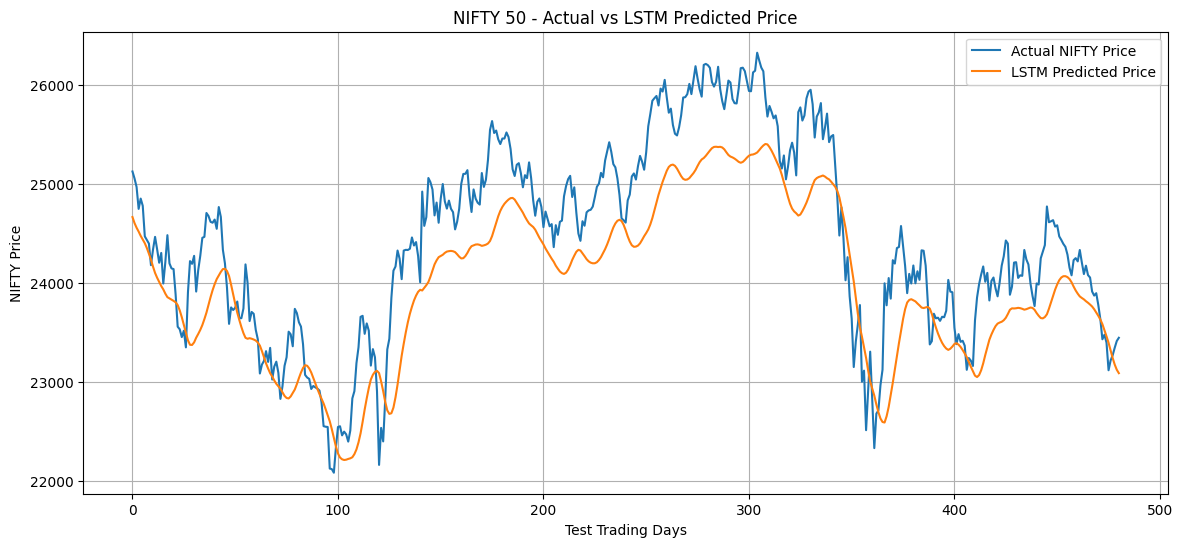

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y_actual_price,
    label="Actual NIFTY Price"
)

plt.plot(
    y_pred_price,
    label="LSTM Predicted Price"
)

plt.title("NIFTY 50 - Actual vs LSTM Predicted Price")
plt.xlabel("Test Trading Days")
plt.ylabel("NIFTY Price")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# LSTM Directional Accuracy

actual_direction = np.diff(y_actual_price) > 0
predicted_direction = np.diff(y_pred_price) > 0

directional_accuracy = np.mean(
    actual_direction == predicted_direction
) * 100

print(f"LSTM Directional Accuracy: {directional_accuracy:.2f}%")

LSTM Directional Accuracy: 50.21%


In [21]:
import os
import joblib
import pandas as pd

# Project paths
PROJECT_DIR = "/content/drive/MyDrive/Share_Market_ML_Project"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Save trained LSTM model
model_path = os.path.join(MODEL_DIR, "NIFTY50_LSTM.keras")
lstm_model.save(model_path)

# 2. Save scaler
scaler_path = os.path.join(MODEL_DIR, "NIFTY50_LSTM_scaler.pkl")
joblib.dump(scaler, scaler_path)

# 3. Save predictions
prediction_df = pd.DataFrame({
    "Actual_NIFTY": y_actual_price,
    "LSTM_Predicted_NIFTY": y_pred_price
})

prediction_path = os.path.join(
    RESULTS_DIR,
    "LSTM_predictions.csv"
)

prediction_df.to_csv(prediction_path, index=False)

# 4. Save performance metrics
metrics_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "Directional Accuracy"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        directional_accuracy
    ]
})

metrics_path = os.path.join(
    RESULTS_DIR,
    "LSTM_performance_metrics.csv"
)

metrics_df.to_csv(metrics_path, index=False)

print("✅ LSTM model saved:")
print(model_path)

print("\n✅ Scaler saved:")
print(scaler_path)

print("\n✅ Predictions saved:")
print(prediction_path)

print("\n✅ Performance metrics saved:")
print(metrics_path)

✅ LSTM model saved:
/content/drive/MyDrive/Share_Market_ML_Project/models/NIFTY50_LSTM.keras

✅ Scaler saved:
/content/drive/MyDrive/Share_Market_ML_Project/models/NIFTY50_LSTM_scaler.pkl

✅ Predictions saved:
/content/drive/MyDrive/Share_Market_ML_Project/results/LSTM_predictions.csv

✅ Performance metrics saved:
/content/drive/MyDrive/Share_Market_ML_Project/results/LSTM_performance_metrics.csv


In [22]:
import pandas as pd
import plotly.graph_objects as go

# Load NIFTY data
data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

df_candle = pd.read_csv(data_path)

# Convert Date
df_candle["Date"] = pd.to_datetime(df_candle["Date"])

# Sort by date
df_candle = df_candle.sort_values("Date").reset_index(drop=True)

# Last 6 months
df_recent = df_candle.tail(125)

# Candlestick chart
fig = go.Figure(
    data=[
        go.Candlestick(
            x=df_recent["Date"],
            open=df_recent["Open"],
            high=df_recent["High"],
            low=df_recent["Low"],
            close=df_recent["Close"],
            name="NIFTY 50"
        )
    ]
)

fig.update_layout(
    title="NIFTY 50 Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="NIFTY Price",
    xaxis_rangeslider_visible=False,
    template="plotly_white",
    height=650
)

fig.show()

In [23]:
import pandas as pd
import plotly.graph_objects as go

# Load NIFTY data
data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

df_chart = pd.read_csv(data_path)

# Date conversion
df_chart["Date"] = pd.to_datetime(df_chart["Date"])
df_chart = df_chart.sort_values("Date").reset_index(drop=True)

# Calculate Moving Averages
df_chart["SMA_20"] = df_chart["Close"].rolling(20).mean()
df_chart["SMA_50"] = df_chart["Close"].rolling(50).mean()

# Last 125 trading days
df_recent = df_chart.tail(125)

# Create chart
fig = go.Figure()

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=df_recent["Date"],
        open=df_recent["Open"],
        high=df_recent["High"],
        low=df_recent["Low"],
        close=df_recent["Close"],
        name="NIFTY 50"
    )
)

# SMA 20
fig.add_trace(
    go.Scatter(
        x=df_recent["Date"],
        y=df_recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    )
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=df_recent["Date"],
        y=df_recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    )
)

# Layout
fig.update_layout(
    title="NIFTY 50 Candlestick with SMA 20 & SMA 50",
    xaxis_title="Date",
    yaxis_title="NIFTY Price",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=650
)

fig.show()

In [24]:
import pandas as pd
import plotly.graph_objects as go

# Load V2 dataset
v2_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_V2.csv"

df_rf_chart = pd.read_csv(v2_path)
df_rf_chart["Date"] = pd.to_datetime(df_rf_chart["Date"])
df_rf_chart = df_rf_chart.sort_values("Date").reset_index(drop=True)

# Last 125 trading days
df_recent = df_rf_chart.tail(125).copy()

# SMA
df_recent["SMA_20"] = df_recent["Close"].rolling(20).mean()
df_recent["SMA_50"] = df_recent["Close"].rolling(50).mean()

fig = go.Figure()

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=df_recent["Date"],
        open=df_recent["Open"],
        high=df_recent["High"],
        low=df_recent["Low"],
        close=df_recent["Close"],
        name="NIFTY 50"
    )
)

# SMA 20
fig.add_trace(
    go.Scatter(
        x=df_recent["Date"],
        y=df_recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    )
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=df_recent["Date"],
        y=df_recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    )
)

fig.update_layout(
    title="NIFTY 50 — Candlestick + Moving Averages",
    xaxis_title="Date",
    yaxis_title="NIFTY Price",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=650
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_V2.csv'

In [25]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Moving averages
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

# Last 125 trading days
recent = df.tail(125).copy()

# Create price + volume chart
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.75, 0.25],
    subplot_titles=("NIFTY 50 Price", "Volume")
)

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=recent["Date"],
        open=recent["Open"],
        high=recent["High"],
        low=recent["Low"],
        close=recent["Close"],
        name="NIFTY 50"
    ),
    row=1,
    col=1
)

# SMA 20
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    ),
    row=1,
    col=1
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    ),
    row=1,
    col=1
)

# Volume
fig.add_trace(
    go.Bar(
        x=recent["Date"],
        y=recent["Volume"],
        name="Volume"
    ),
    row=2,
    col=1
)

fig.update_layout(
    title="NIFTY 50 — Candlestick + SMA 20 + SMA 50 + Volume",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=800
)

fig.update_yaxes(title_text="NIFTY Price", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)

fig.show()

In [26]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Moving averages
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

# Last 125 trading days
recent = df.tail(125).copy()

# Create price + volume chart
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.75, 0.25],
    subplot_titles=("NIFTY 50 Price", "Volume")
)

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=recent["Date"],
        open=recent["Open"],
        high=recent["High"],
        low=recent["Low"],
        close=recent["Close"],
        name="NIFTY 50"
    ),
    row=1,
    col=1
)

# SMA 20
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    ),
    row=1,
    col=1
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    ),
    row=1,
    col=1
)

# Volume
fig.add_trace(
    go.Bar(
        x=recent["Date"],
        y=recent["Volume"],
        name="Volume"
    ),
    row=2,
    col=1
)

fig.update_layout(
    title="NIFTY 50 — Candlestick + SMA 20 + SMA 50 + Volume",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=800
)

fig.update_yaxes(title_text="NIFTY Price", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)

fig.show()

In [28]:
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=[0.50, 0.15, 0.17, 0.18],
    subplot_titles=(
        "NIFTY 50 Price",
        "Volume",
        "RSI (14)",
        "MACD"
    )
)

# -------------------------
# PRICE + CANDLE
# -------------------------

fig.add_trace(
    go.Candlestick(
        x=recent["Date"],
        open=recent["Open"],
        high=recent["High"],
        low=recent["Low"],
        close=recent["Close"],
        name="NIFTY 50"
    ),
    row=1,
    col=1
)

# SMA 20
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    ),
    row=1,
    col=1
)

# SMA 50
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    ),
    row=1,
    col=1
)

# -------------------------
# VOLUME
# -------------------------

fig.add_trace(
    go.Bar(
        x=recent["Date"],
        y=recent["Volume"],
        name="Volume"
    ),
    row=2,
    col=1
)

# -------------------------
# RSI
# -------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["RSI_14"],
        mode="lines",
        name="RSI 14"
    ),
    row=3,
    col=1
)

# RSI 70
fig.add_hline(
    y=70,
    line_dash="dash",
    row=3,
    col=1
)

# RSI 30
fig.add_hline(
    y=30,
    line_dash="dash",
    row=3,
    col=1
)

# -------------------------
# MACD
# -------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD"],
        mode="lines",
        name="MACD"
    ),
    row=4,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD_Signal"],
        mode="lines",
        name="Signal"
    ),
    row=4,
    col=1
)

# Layout
fig.update_layout(
    title="NIFTY 50 Technical Analysis Dashboard",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=1100
)

fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)
fig.update_yaxes(title_text="RSI", row=3, col=1)
fig.update_yaxes(title_text="MACD", row=4, col=1)

fig.show()

KeyError: 'RSI_14'

In [29]:
# ============================================================
# NIFTY 50 - Candlestick + SMA20 + SMA50 + Volume + RSI + MACD
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

df = pd.read_csv(data_path)

# Clean column names
df.columns = df.columns.str.strip()

# Date
df["Date"] = pd.to_datetime(df["Date"])

# Sort
df = df.sort_values("Date").reset_index(drop=True)

print("Columns:", df.columns.tolist())
print("Rows:", len(df))


# ------------------------------------------------------------
# 2. Moving Averages
# ------------------------------------------------------------

df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()


# ------------------------------------------------------------
# 3. RSI 14
# ------------------------------------------------------------

delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

# Avoid division by zero
rs = avg_gain / avg_loss.replace(0, np.nan)

df["RSI_14"] = 100 - (100 / (1 + rs))


# ------------------------------------------------------------
# 4. MACD
# ------------------------------------------------------------

ema_12 = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = ema_12 - ema_26

df["MACD_Signal"] = df["MACD"].ewm(
    span=9,
    adjust=False
).mean()


# ------------------------------------------------------------
# 5. Last 125 trading days
# ------------------------------------------------------------

recent = df.tail(125).copy()


# ------------------------------------------------------------
# 6. Create 4-row chart
# ------------------------------------------------------------

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.035,
    row_heights=[0.50, 0.15, 0.17, 0.18],
    subplot_titles=[
        "NIFTY 50 Price",
        "Volume",
        "RSI (14)",
        "MACD"
    ]
)


# ------------------------------------------------------------
# 7. Candlestick
# ------------------------------------------------------------

fig.add_trace(
    go.Candlestick(
        x=recent["Date"],
        open=recent["Open"],
        high=recent["High"],
        low=recent["Low"],
        close=recent["Close"],
        name="NIFTY 50"
    ),
    row=1,
    col=1
)


# ------------------------------------------------------------
# 8. SMA 20
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    ),
    row=1,
    col=1
)


# ------------------------------------------------------------
# 9. SMA 50
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    ),
    row=1,
    col=1
)


# ------------------------------------------------------------
# 10. Volume
# ------------------------------------------------------------

fig.add_trace(
    go.Bar(
        x=recent["Date"],
        y=recent["Volume"],
        name="Volume"
    ),
    row=2,
    col=1
)


# ------------------------------------------------------------
# 11. RSI
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["RSI_14"],
        mode="lines",
        name="RSI 14"
    ),
    row=3,
    col=1
)

# RSI 70
fig.add_hline(
    y=70,
    line_dash="dash",
    row=3,
    col=1
)

# RSI 30
fig.add_hline(
    y=30,
    line_dash="dash",
    row=3,
    col=1
)


# ------------------------------------------------------------
# 12. MACD
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD"],
        mode="lines",
        name="MACD"
    ),
    row=4,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD_Signal"],
        mode="lines",
        name="Signal"
    ),
    row=4,
    col=1
)


# ------------------------------------------------------------
# 13. Layout
# ------------------------------------------------------------

fig.update_layout(
    title="NIFTY 50 Technical Analysis Dashboard",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=1100
)

fig.update_yaxes(
    title_text="Price",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Volume",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="RSI",
    range=[0, 100],
    row=3,
    col=1
)

fig.update_yaxes(
    title_text="MACD",
    row=4,
    col=1
)

fig.show()

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Rows: 2464


In [30]:
df["RSI_14"] = 100 - (100 / (1 + rs))

In [31]:
print(type(rf_model))

NameError: name 'rf_model' is not defined

In [32]:
# ============================================================
# RANDOM FOREST - REBUILD + SAVE
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/Share_Market_ML_Project"

DATA_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "NIFTY50_LSTM_raw.csv"
)

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


# ------------------------------------------------------------
# 2. Load NIFTY data
# ------------------------------------------------------------

df_rf = pd.read_csv(DATA_PATH)

df_rf["Date"] = pd.to_datetime(df_rf["Date"])

df_rf = (
    df_rf
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Raw data:", df_rf.shape)


# ------------------------------------------------------------
# 3. Feature Engineering
# ------------------------------------------------------------

df_rf["Daily_Return"] = df_rf["Close"].pct_change()

df_rf["Price_Change"] = df_rf["Close"].diff()

df_rf["SMA_20"] = (
    df_rf["Close"]
    .rolling(window=20)
    .mean()
)

df_rf["SMA_50"] = (
    df_rf["Close"]
    .rolling(window=50)
    .mean()
)

df_rf["Volume_Change"] = (
    df_rf["Volume"]
    .pct_change()
)


# RSI 14
delta = df_rf["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss.replace(0, np.nan)

df_rf["RSI_14"] = (
    100 - (100 / (1 + rs))
)


# MACD
ema_12 = df_rf["Close"].ewm(
    span=12,
    adjust=False
).mean()

ema_26 = df_rf["Close"].ewm(
    span=26,
    adjust=False
).mean()

df_rf["MACD"] = ema_12 - ema_26


# Volatility
df_rf["Volatility_20"] = (
    df_rf["Daily_Return"]
    .rolling(window=20)
    .std()
)


# ------------------------------------------------------------
# 4. Future Return
# ------------------------------------------------------------

df_rf["Future_Return"] = (
    df_rf["Close"].shift(-1)
    / df_rf["Close"]
    - 1
)


# ------------------------------------------------------------
# 5. Future Trend
# ------------------------------------------------------------

def classify_future_trend(x):

    if x > 0.005:
        return "UP"

    elif x < -0.005:
        return "DOWN"

    else:
        return "SIDEWAYS"


df_rf["Future_Trend"] = (
    df_rf["Future_Return"]
    .apply(classify_future_trend)
)


# ------------------------------------------------------------
# 6. Select features
# ------------------------------------------------------------

features = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]


# Remove missing values
df_rf = df_rf.dropna().reset_index(drop=True)

print("ML dataset:", df_rf.shape)

print("\nTarget distribution:")
print(df_rf["Future_Trend"].value_counts())


# ------------------------------------------------------------
# 7. Chronological 80/20 split
# ------------------------------------------------------------

X = df_rf[features]
y = df_rf["Future_Trend"]

split_index = int(len(df_rf) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)

print(
    "\nTrain dates:",
    df_rf["Date"].iloc[0].date(),
    "to",
    df_rf["Date"].iloc[split_index - 1].date()
)

print(
    "Test dates :",
    df_rf["Date"].iloc[split_index].date(),
    "to",
    df_rf["Date"].iloc[-1].date()
)


# ------------------------------------------------------------
# 8. Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# ------------------------------------------------------------
# 9. Prediction
# ------------------------------------------------------------

rf_pred = rf_model.predict(X_test)


# ------------------------------------------------------------
# 10. Performance
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, rf_pred)

precision = precision_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

print("\n===== RANDOM FOREST PERFORMANCE =====")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"Macro F1 : {macro_f1 * 100:.2f}%")


# ------------------------------------------------------------
# 11. Save model
# ------------------------------------------------------------

rf_model_path = os.path.join(
    MODEL_DIR,
    "NIFTY50_RandomForest.pkl"
)

joblib.dump(
    rf_model,
    rf_model_path
)


# ------------------------------------------------------------
# 12. Save test predictions
# ------------------------------------------------------------

rf_results = df_rf.iloc[split_index:].copy()

rf_results["Predicted_Trend"] = rf_pred

rf_results_path = os.path.join(
    RESULTS_DIR,
    "RandomForest_predictions.csv"
)

rf_results.to_csv(
    rf_results_path,
    index=False
)


print("\n✅ Random Forest saved:")
print(rf_model_path)

print("\n✅ Predictions saved:")
print(rf_results_path)

Raw data: (2464, 6)
ML dataset: (2410, 16)

Target distribution:
Future_Trend
SIDEWAYS    1182
UP           692
DOWN         536
Name: count, dtype: int64

Train: (1928, 8)
Test : (482, 8)

Train dates: 2016-12-08 to 2024-10-09
Test dates : 2024-10-10 to 2026-09-21


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [33]:
Volume_Change = Volume.pct_change()

NameError: name 'Volume' is not defined

In [34]:
# Check target and infinity problems

print("===== TARGET CHECK =====")
print(df_rf["Future_Trend"].value_counts(dropna=False))

print("\n===== FUTURE RETURN CHECK =====")
print(df_rf["Future_Return"].describe())

print("\n===== INFINITY CHECK =====")

inf_counts = np.isinf(
    df_rf[features].select_dtypes(include=np.number)
).sum()

print(inf_counts)

print("\nTotal infinity values:",
      np.isinf(df_rf[features].select_dtypes(include=np.number)).sum().sum())

===== TARGET CHECK =====
Future_Trend
SIDEWAYS    1182
UP           692
DOWN         536
Name: count, dtype: int64

===== FUTURE RETURN CHECK =====
count    2410.000000
mean        0.000483
std         0.010222
min        -0.129805
25%        -0.004227
50%         0.000647
75%         0.005800
max         0.087632
Name: Future_Return, dtype: float64

===== INFINITY CHECK =====
Daily_Return      0
Price_Change      0
SMA_20            0
SMA_50            0
Volume_Change    25
RSI_14            0
MACD              0
Volatility_20     0
dtype: int64

Total infinity values: 25


In [35]:
# Replace infinity values with NaN
df_rf = df_rf.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows containing NaN in ML features
df_rf = df_rf.dropna(
    subset=features
).reset_index(drop=True)

print("Dataset after infinity cleanup:", df_rf.shape)

print("\nTarget distribution:")
print(df_rf["Future_Trend"].value_counts())

print("\nInfinity values remaining:")

print(
    np.isinf(
        df_rf[features].select_dtypes(include=np.number)
    ).sum().sum()
)

Dataset after infinity cleanup: (2385, 16)

Target distribution:
Future_Trend
SIDEWAYS    1172
UP           681
DOWN         532
Name: count, dtype: int64

Infinity values remaining:
0


In [36]:
# ============================================================
# RANDOM FOREST TRAINING AFTER CLEANUP
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import joblib
import os

# Features and target
X = df_rf[features]
y = df_rf["Future_Trend"]

# Chronological 80/20 split
split_index = int(len(df_rf) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain dates:")
print(
    df_rf["Date"].iloc[0],
    "to",
    df_rf["Date"].iloc[split_index - 1]
)

print("\nTest dates:")
print(
    df_rf["Date"].iloc[split_index],
    "to",
    df_rf["Date"].iloc[-1]
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, rf_pred)

precision = precision_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro",
    zero_division=0
)

print("\n===== RANDOM FOREST PERFORMANCE =====")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"Macro F1 : {macro_f1 * 100:.2f}%")

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

Train: (1908, 8)
Test : (477, 8)

Train dates:
2016-12-08 00:00:00 to 2024-10-16 00:00:00

Test dates:
2024-10-17 00:00:00 to 2026-09-21 00:00:00

===== RANDOM FOREST PERFORMANCE =====
Accuracy : 49.90%
Precision: 33.71%
Recall   : 35.95%
Macro F1 : 31.75%

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        DOWN       0.17      0.01      0.02       108
    SIDEWAYS       0.57      0.81      0.67       256
          UP       0.28      0.26      0.27       113

    accuracy                           0.50       477
   macro avg       0.34      0.36      0.32       477
weighted avg       0.41      0.50      0.43       477



In [37]:
# Save cleaned Random Forest model

import os
import joblib
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Share_Market_ML_Project"

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

# Save model
rf_model_path = os.path.join(
    MODEL_DIR,
    "NIFTY50_RandomForest_clean.pkl"
)

joblib.dump(
    rf_model,
    rf_model_path
)

# Save predictions with dates
rf_prediction_df = df_rf.iloc[split_index:].copy()

rf_prediction_df["Predicted_Trend"] = rf_pred

rf_prediction_path = os.path.join(
    RESULTS_DIR,
    "RandomForest_clean_predictions.csv"
)

rf_prediction_df.to_csv(
    rf_prediction_path,
    index=False
)

print("✅ Random Forest model saved:")
print(rf_model_path)

print("\n✅ Predictions saved:")
print(rf_prediction_path)

✅ Random Forest model saved:
/content/drive/MyDrive/Share_Market_ML_Project/models/NIFTY50_RandomForest_clean.pkl

✅ Predictions saved:
/content/drive/MyDrive/Share_Market_ML_Project/results/RandomForest_clean_predictions.csv


In [38]:
# ============================================================
# NIFTY 50 - Candlestick + Indicators + Random Forest Signals
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# 1. Use cleaned RF dataset already in memory
# ------------------------------------------------------------

chart_df = df_rf.copy()

chart_df["Date"] = pd.to_datetime(chart_df["Date"])

chart_df = chart_df.sort_values("Date").reset_index(drop=True)


# ------------------------------------------------------------
# 2. Add RF predictions
# ------------------------------------------------------------

# Create prediction column
chart_df["RF_Prediction"] = np.nan

# Test-period predictions
chart_df.loc[
    split_index:,
    "RF_Prediction"
] = rf_pred


# ------------------------------------------------------------
# 3. Calculate MACD Signal
# ------------------------------------------------------------

chart_df["MACD_Signal"] = (
    chart_df["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)


# ------------------------------------------------------------
# 4. Last 125 trading days
# ------------------------------------------------------------

recent = chart_df.tail(125).copy()


# ------------------------------------------------------------
# 5. Create chart
# ------------------------------------------------------------

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.035,
    row_heights=[0.48, 0.14, 0.18, 0.20],
    subplot_titles=[
        "NIFTY 50 Price + Random Forest Signals",
        "Volume",
        "RSI (14)",
        "MACD"
    ]
)


# ============================================================
# PRICE / CANDLE
# ============================================================

fig.add_trace(
    go.Candlestick(
        x=recent["Date"],
        open=recent["Open"],
        high=recent["High"],
        low=recent["Low"],
        close=recent["Close"],
        name="NIFTY 50"
    ),
    row=1,
    col=1
)


# SMA 20
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_20"],
        mode="lines",
        name="SMA 20"
    ),
    row=1,
    col=1
)


# SMA 50
fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["SMA_50"],
        mode="lines",
        name="SMA 50"
    ),
    row=1,
    col=1
)


# ============================================================
# RANDOM FOREST SIGNALS
# ============================================================

# UP
up = recent[
    recent["RF_Prediction"] == "UP"
]

fig.add_trace(
    go.Scatter(
        x=up["Date"],
        y=up["Low"] * 0.995,
        mode="markers",
        marker=dict(
            symbol="triangle-up",
            size=10
        ),
        name="RF UP"
    ),
    row=1,
    col=1
)


# DOWN
down = recent[
    recent["RF_Prediction"] == "DOWN"
]

fig.add_trace(
    go.Scatter(
        x=down["Date"],
        y=down["High"] * 1.005,
        mode="markers",
        marker=dict(
            symbol="triangle-down",
            size=10
        ),
        name="RF DOWN"
    ),
    row=1,
    col=1
)


# SIDEWAYS
sideways = recent[
    recent["RF_Prediction"] == "SIDEWAYS"
]

fig.add_trace(
    go.Scatter(
        x=sideways["Date"],
        y=sideways["Close"],
        mode="markers",
        marker=dict(
            symbol="circle",
            size=6
        ),
        name="RF SIDEWAYS"
    ),
    row=1,
    col=1
)


# ============================================================
# VOLUME
# ============================================================

fig.add_trace(
    go.Bar(
        x=recent["Date"],
        y=recent["Volume"],
        name="Volume"
    ),
    row=2,
    col=1
)


# ============================================================
# RSI
# ============================================================

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["RSI_14"],
        mode="lines",
        name="RSI 14"
    ),
    row=3,
    col=1
)

fig.add_hline(
    y=70,
    line_dash="dash",
    row=3,
    col=1
)

fig.add_hline(
    y=30,
    line_dash="dash",
    row=3,
    col=1
)


# ============================================================
# MACD
# ============================================================

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD"],
        mode="lines",
        name="MACD"
    ),
    row=4,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=recent["Date"],
        y=recent["MACD_Signal"],
        mode="lines",
        name="MACD Signal"
    ),
    row=4,
    col=1
)


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(
    title="NIFTY 50 ML Technical Analysis Dashboard",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=1100
)

fig.update_yaxes(
    title_text="Price",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Volume",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="RSI",
    range=[0, 100],
    row=3,
    col=1
)

fig.update_yaxes(
    title_text="MACD",
    row=4,
    col=1
)

fig.show()

/tmp/ipykernel_3497/1300152996.py:29: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['UP' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS' 'UP'
 'UP' 'UP' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP'
 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS'
 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS' 'UP'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'UP' 'UP' 'UP'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 

In [39]:
import pandas as pd
import numpy as np

# Load NIFTY data
data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

hammer_df = pd.read_csv(data_path)

hammer_df["Date"] = pd.to_datetime(hammer_df["Date"])
hammer_df = hammer_df.sort_values("Date").reset_index(drop=True)

# ---------------------------------------------------------
# Candle calculations
# ---------------------------------------------------------

hammer_df["Body"] = (
    abs(hammer_df["Close"] - hammer_df["Open"])
)

hammer_df["Upper_Shadow"] = (
    hammer_df["High"]
    - hammer_df[["Open", "Close"]].max(axis=1)
)

hammer_df["Lower_Shadow"] = (
    hammer_df[["Open", "Close"]].min(axis=1)
    - hammer_df["Low"]
)

# ---------------------------------------------------------
# Hammer condition
# ---------------------------------------------------------

hammer_df["Hammer"] = (
    (hammer_df["Body"] > 0) &
    (hammer_df["Lower_Shadow"] >= 2 * hammer_df["Body"]) &
    (hammer_df["Upper_Shadow"] <= 0.5 * hammer_df["Body"])
)

print("Total candles:", len(hammer_df))
print("Hammer candles:", hammer_df["Hammer"].sum())

print("\nLatest Hammer patterns:")
print(
    hammer_df.loc[
        hammer_df["Hammer"],
        ["Date", "Open", "High", "Low", "Close",
         "Body", "Upper_Shadow", "Lower_Shadow"]
    ].tail(10)
)

Total candles: 2464
Hammer candles: 72

Latest Hammer patterns:
           Date      Open      High       Low     Close   Body  Upper_Shadow  \
2112 2025-04-23  24357.60  24359.30  24119.95  24328.95  28.65          1.70   
2163 2025-07-04  25428.85  25470.25  25331.65  25461.00  32.15          9.25   
2181 2025-07-30  24890.40  24902.30  24771.95  24855.05  35.35         11.90   
2215 2025-09-18  25441.05  25448.95  25329.75  25423.60  17.45          7.90   
2250 2025-11-11  25617.00  25715.80  25449.25  25694.95  77.95         20.85   
2429 2026-08-04  24703.90  24703.90  24427.95  24614.90  89.00          0.00   
2430 2026-08-05  24669.20  24677.60  24497.95  24624.65  44.55          8.40   
2435 2026-08-12  24472.45  24473.30  24265.95  24435.95  36.50          0.85   
2436 2026-08-13  24431.60  24431.60  24311.40  24395.85  35.75          0.00   
2448 2026-08-31  24117.55  24128.70  23993.60  24080.40  37.15         11.15   

      Lower_Shadow  
2112        209.00  
2163         

In [40]:
import plotly.graph_objects as go

# Last 125 trading days
recent_hammer = hammer_df.tail(125).copy()

# Only Hammer candles
hammer_points = recent_hammer[
    recent_hammer["Hammer"]
]

fig = go.Figure()

# Candlestick
fig.add_trace(
    go.Candlestick(
        x=recent_hammer["Date"],
        open=recent_hammer["Open"],
        high=recent_hammer["High"],
        low=recent_hammer["Low"],
        close=recent_hammer["Close"],
        name="NIFTY 50"
    )
)

# Hammer markers
fig.add_trace(
    go.Scatter(
        x=hammer_points["Date"],
        y=hammer_points["Low"] * 0.995,
        mode="markers",
        marker=dict(
            symbol="triangle-up",
            size=12
        ),
        name="Hammer"
    )
)

fig.update_layout(
    title="NIFTY 50 — Hammer Candlestick Pattern Detection",
    xaxis_title="Date",
    yaxis_title="NIFTY Price",
    xaxis_rangeslider_visible=False,
    hovermode="x unified",
    template="plotly_white",
    height=650
)

fig.show()

In [41]:
import pandas as pd
import numpy as np

# Load NIFTY data
data_path = "/content/drive/MyDrive/Share_Market_ML_Project/data/NIFTY50_LSTM_raw.csv"

pattern_df = pd.read_csv(data_path)

pattern_df["Date"] = pd.to_datetime(pattern_df["Date"])
pattern_df = pattern_df.sort_values("Date").reset_index(drop=True)

# ============================================================
# Candle calculations
# ============================================================

pattern_df["Body"] = abs(
    pattern_df["Close"] - pattern_df["Open"]
)

pattern_df["Range"] = (
    pattern_df["High"] - pattern_df["Low"]
)

pattern_df["Upper_Shadow"] = (
    pattern_df["High"]
    - pattern_df[["Open", "Close"]].max(axis=1)
)

pattern_df["Lower_Shadow"] = (
    pattern_df[["Open", "Close"]].min(axis=1)
    - pattern_df["Low"]
)


# ============================================================
# 1. HAMMER
# ============================================================

pattern_df["Hammer"] = (
    (pattern_df["Body"] > 0) &
    (pattern_df["Lower_Shadow"] >= 2 * pattern_df["Body"]) &
    (pattern_df["Upper_Shadow"] <= 0.5 * pattern_df["Body"])
)


# ============================================================
# 2. DOJI
# ============================================================

# Body is very small compared with total candle range

pattern_df["Doji"] = (
    (pattern_df["Range"] > 0) &
    (pattern_df["Body"] <= 0.10 * pattern_df["Range"])
)


# ============================================================
# 3. BULLISH ENGULFING
# ============================================================

previous_open = pattern_df["Open"].shift(1)
previous_close = pattern_df["Close"].shift(1)

previous_bearish = (
    previous_close < previous_open
)

current_bullish = (
    pattern_df["Close"] > pattern_df["Open"]
)

pattern_df["Bullish_Engulfing"] = (
    previous_bearish &
    current_bullish &
    (pattern_df["Open"] <= previous_close) &
    (pattern_df["Close"] >= previous_open)
)


# ============================================================
# 4. BEARISH ENGULFING
# ============================================================

previous_bullish = (
    previous_close > previous_open
)

current_bearish = (
    pattern_df["Close"] < pattern_df["Open"]
)

pattern_df["Bearish_Engulfing"] = (
    previous_bullish &
    current_bearish &
    (pattern_df["Open"] >= previous_close) &
    (pattern_df["Close"] <= previous_open)
)


# ============================================================
# 5. SHOOTING STAR
# ============================================================

pattern_df["Shooting_Star"] = (
    (pattern_df["Body"] > 0) &
    (pattern_df["Upper_Shadow"] >= 2 * pattern_df["Body"]) &
    (pattern_df["Lower_Shadow"] <= 0.5 * pattern_df["Body"])
)


# ============================================================
# Pattern summary
# ============================================================

print("===== CANDLESTICK PATTERN SUMMARY =====")

print(
    "Hammer:",
    int(pattern_df["Hammer"].sum())
)

print(
    "Doji:",
    int(pattern_df["Doji"].sum())
)

print(
    "Bullish Engulfing:",
    int(pattern_df["Bullish_Engulfing"].sum())
)

print(
    "Bearish Engulfing:",
    int(pattern_df["Bearish_Engulfing"].sum())
)

print(
    "Shooting Star:",
    int(pattern_df["Shooting_Star"].sum())
)

===== CANDLESTICK PATTERN SUMMARY =====
Hammer: 72
Doji: 215
Bullish Engulfing: 44
Bearish Engulfing: 113
Shooting Star: 24


In [42]:
# ============================================================
# ADDITIONAL CANDLESTICK PATTERNS
# ============================================================

# Previous / next candle values
prev_open = pattern_df["Open"].shift(1)
prev_close = pattern_df["Close"].shift(1)

prev2_open = pattern_df["Open"].shift(2)
prev2_close = pattern_df["Close"].shift(2)


# ============================================================
# 6. INVERTED HAMMER
# ============================================================

pattern_df["Inverted_Hammer"] = (
    (pattern_df["Body"] > 0) &
    (pattern_df["Upper_Shadow"] >= 2 * pattern_df["Body"]) &
    (pattern_df["Lower_Shadow"] <= 0.5 * pattern_df["Body"])
)


# ============================================================
# 7. HANGING MAN
# ============================================================

pattern_df["Hanging_Man"] = (
    (pattern_df["Body"] > 0) &
    (pattern_df["Lower_Shadow"] >= 2 * pattern_df["Body"]) &
    (pattern_df["Upper_Shadow"] <= 0.5 * pattern_df["Body"])
)


# ============================================================
# 8. BULLISH MARUBOZU
# ============================================================

pattern_df["Bullish_Marubozu"] = (
    (pattern_df["Close"] > pattern_df["Open"]) &
    (pattern_df["Upper_Shadow"] <= 0.05 * pattern_df["Range"]) &
    (pattern_df["Lower_Shadow"] <= 0.05 * pattern_df["Range"])
)


# ============================================================
# 9. BEARISH MARUBOZU
# ============================================================

pattern_df["Bearish_Marubozu"] = (
    (pattern_df["Close"] < pattern_df["Open"]) &
    (pattern_df["Upper_Shadow"] <= 0.05 * pattern_df["Range"]) &
    (pattern_df["Lower_Shadow"] <= 0.05 * pattern_df["Range"])
)


# ============================================================
# 10. PIERCING LINE
# ============================================================

pattern_df["Piercing_Line"] = (
    (prev_close < prev_open) &
    (pattern_df["Close"] > pattern_df["Open"]) &
    (pattern_df["Open"] < prev_close) &
    (pattern_df["Close"] > (prev_open + prev_close) / 2) &
    (pattern_df["Close"] < prev_open)
)


# ============================================================
# 11. DARK CLOUD COVER
# ============================================================

pattern_df["Dark_Cloud_Cover"] = (
    (prev_close > prev_open) &
    (pattern_df["Close"] < pattern_df["Open"]) &
    (pattern_df["Open"] > prev_close) &
    (pattern_df["Close"] < (prev_open + prev_close) / 2) &
    (pattern_df["Close"] > prev_open)
)


# ============================================================
# 12. MORNING STAR
# ============================================================

first_bearish = prev2_close < prev2_open
middle_small = (
    abs(prev_close - prev_open)
    <= 0.30 * pattern_df["Range"].shift(1)
)
third_bullish = pattern_df["Close"] > pattern_df["Open"]

pattern_df["Morning_Star"] = (
    first_bearish &
    middle_small &
    third_bullish &
    (
        pattern_df["Close"]
        > (prev2_open + prev2_close) / 2
    )
)


# ============================================================
# 13. EVENING STAR
# ============================================================

first_bullish = prev2_close > prev2_open
third_bearish = pattern_df["Close"] < pattern_df["Open"]

pattern_df["Evening_Star"] = (
    first_bullish &
    middle_small &
    third_bearish &
    (
        pattern_df["Close"]
        < (prev2_open + prev2_close) / 2
    )
)


# ============================================================
# 14. THREE WHITE SOLDIERS
# ============================================================

c1_bull = prev2_close > prev2_open
c2_bull = prev_close > prev_open
c3_bull = pattern_df["Close"] > pattern_df["Open"]

pattern_df["Three_White_Soldiers"] = (
    c1_bull &
    c2_bull &
    c3_bull &
    (prev_close > prev2_close) &
    (pattern_df["Close"] > prev_close)
)


# ============================================================
# 15. THREE BLACK CROWS
# ============================================================

c1_bear = prev2_close < prev2_open
c2_bear = prev_close < prev_open
c3_bear = pattern_df["Close"] < pattern_df["Open"]

pattern_df["Three_Black_Crows"] = (
    c1_bear &
    c2_bear &
    c3_bear &
    (prev_close < prev2_close) &
    (pattern_df["Close"] < prev_close)
)


# ============================================================
# SUMMARY
# ============================================================

additional_patterns = [
    "Inverted_Hammer",
    "Hanging_Man",
    "Bullish_Marubozu",
    "Bearish_Marubozu",
    "Piercing_Line",
    "Dark_Cloud_Cover",
    "Morning_Star",
    "Evening_Star",
    "Three_White_Soldiers",
    "Three_Black_Crows"
]

print("===== ADDITIONAL PATTERN SUMMARY =====")

for pattern in additional_patterns:
    print(
        f"{pattern}:",
        int(pattern_df[pattern].sum())
    )

===== ADDITIONAL PATTERN SUMMARY =====
Inverted_Hammer: 24
Hanging_Man: 72
Bullish_Marubozu: 4
Bearish_Marubozu: 5
Piercing_Line: 37
Dark_Cloud_Cover: 54
Morning_Star: 119
Evening_Star: 79
Three_White_Soldiers: 191
Three_Black_Crows: 230


In [43]:
# ==========================================
# CANDLESTICK PATTERN PERFORMANCE ANALYSIS
# 1, 3, 5 DAYS FORWARD RETURNS
# ==========================================

import pandas as pd
import numpy as np

# Use pattern_df already created
analysis_df = pattern_df.copy()

# Forward returns
analysis_df["Return_1D"] = (
    analysis_df["Close"].shift(-1) / analysis_df["Close"] - 1
) * 100

analysis_df["Return_3D"] = (
    analysis_df["Close"].shift(-3) / analysis_df["Close"] - 1
) * 100

analysis_df["Return_5D"] = (
    analysis_df["Close"].shift(-5) / analysis_df["Close"] - 1
) * 100


# All 15 patterns
patterns = [
    "Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Shooting_Star",
    "Inverted_Hammer",
    "Hanging_Man",
    "Bullish_Marubozu",
    "Bearish_Marubozu",
    "Piercing_Line",
    "Dark_Cloud_Cover",
    "Morning_Star",
    "Evening_Star",
    "Three_White_Soldiers",
    "Three_Black_Crows"
]


results = []


for pattern in patterns:

    if pattern not in analysis_df.columns:
        continue

    signal_df = analysis_df[analysis_df[pattern] == True].copy()

    if len(signal_df) == 0:
        continue

    result = {
        "Pattern": pattern,
        "Occurrences": len(signal_df),

        "Avg_Return_1D_%": signal_df["Return_1D"].mean(),
        "Positive_1D_%": (signal_df["Return_1D"] > 0).mean() * 100,

        "Avg_Return_3D_%": signal_df["Return_3D"].mean(),
        "Positive_3D_%": (signal_df["Return_3D"] > 0).mean() * 100,

        "Avg_Return_5D_%": signal_df["Return_5D"].mean(),
        "Positive_5D_%": (signal_df["Return_5D"] > 0).mean() * 100
    }

    results.append(result)


pattern_performance = pd.DataFrame(results)

# Round values
numeric_cols = pattern_performance.columns[2:]

pattern_performance[numeric_cols] = pattern_performance[numeric_cols].round(2)

# Display
print("===== CANDLESTICK PATTERN PERFORMANCE =====")

display(pattern_performance)

===== CANDLESTICK PATTERN PERFORMANCE =====


,Pattern,Occurrences,Avg_Return_1D_%,Positive_1D_%,Avg_Return_3D_%,Positive_3D_%,Avg_Return_5D_%,Positive_5D_%
0,Hammer,72,-0.01,58.33,-0.08,47.22,0.06,50.00
1,Doji,215,0.04,49.77,0.20,57.21,0.36,54.42
2,Bullish_Engulfing,44,0.05,50.00,0.19,54.55,0.12,54.55
3,Bearish_Engulfing,113,0.11,56.64,0.25,53.98,0.23,53.98
4,Shooting_Star,24,0.29,45.83,-0.10,41.67,-0.35,37.50
5,Inverted_Hammer,24,0.29,45.83,-0.10,41.67,-0.35,37.50
6,Hanging_Man,72,-0.01,58.33,-0.08,47.22,0.06,50.00
7,Bullish_Marubozu,4,0.01,75.00,0.24,50.00,-0.14,25.00
8,Bearish_Marubozu,5,-0.20,60.00,0.81,60.00,0.96,80.00
9,Piercing_Line,37,0.07,59.46,-0.00,62.16,-0.30,48.65


In [44]:
output_path = "/content/drive/MyDrive/Share_Market_ML_Project/results/Candlestick_Pattern_Performance.csv"

pattern_performance.to_csv(output_path, index=False)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/drive/MyDrive/Share_Market_ML_Project/results/Candlestick_Pattern_Performance.csv


In [45]:
# ============================================================
# COMBINED ML + TECHNICAL SIGNAL ANALYSIS
# Candlestick + RSI + MACD + SMA + Random Forest
# ============================================================

import numpy as np
import pandas as pd

combined_df = df_rf.copy()

# ------------------------------------------------------------
# 1. RF Prediction
# ------------------------------------------------------------

combined_df["RF_Prediction"] = np.nan

# RF predictions belong to test period
combined_df.loc[split_index:, "RF_Prediction"] = rf_pred

# ------------------------------------------------------------
# 2. Technical Signals
# ------------------------------------------------------------

combined_df["RSI_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["RSI_14"] < 30,
    "RSI_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["RSI_14"] > 70,
    "RSI_Signal"
] = "BEARISH"


combined_df["MACD_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["MACD"] > 0,
    "MACD_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["MACD"] < 0,
    "MACD_Signal"
] = "BEARISH"


combined_df["SMA_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["SMA_20"] > combined_df["SMA_50"],
    "SMA_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["SMA_20"] < combined_df["SMA_50"],
    "SMA_Signal"
] = "BEARISH"


# ------------------------------------------------------------
# 3. Candlestick Signal
# ------------------------------------------------------------

bullish_patterns = [
    "Hammer",
    "Bullish_Engulfing",
    "Inverted_Hammer",
    "Bullish_Marubozu",
    "Piercing_Line",
    "Morning_Star",
    "Three_White_Soldiers"
]

bearish_patterns = [
    "Bearish_Engulfing",
    "Shooting_Star",
    "Hanging_Man",
    "Bearish_Marubozu",
    "Dark_Cloud_Cover",
    "Evening_Star",
    "Three_Black_Crows"
]

combined_df["Candlestick_Signal"] = "NEUTRAL"

for pattern in bullish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BULLISH"

for pattern in bearish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BEARISH"


# ------------------------------------------------------------
# 4. Signal Score
# ------------------------------------------------------------

combined_df["Signal_Score"] = 0

combined_df.loc[
    combined_df["RSI_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["RSI_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1


combined_df.loc[
    combined_df["MACD_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["MACD_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1


combined_df.loc[
    combined_df["SMA_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["SMA_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1


combined_df.loc[
    combined_df["Candlestick_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["Candlestick_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1


# RF contribution
combined_df.loc[
    combined_df["RF_Prediction"] == "UP",
    "Signal_Score"
] += 2

combined_df.loc[
    combined_df["RF_Prediction"] == "DOWN",
    "Signal_Score"
] -= 2


# ------------------------------------------------------------
# 5. Final Combined Signal
# ------------------------------------------------------------

combined_df["Combined_Signal"] = "SIDEWAYS"

combined_df.loc[
    combined_df["Signal_Score"] >= 3,
    "Combined_Signal"
] = "UP"

combined_df.loc[
    combined_df["Signal_Score"] <= -3,
    "Combined_Signal"
] = "DOWN"


# ------------------------------------------------------------
# 6. Display latest signals
# ------------------------------------------------------------

display(
    combined_df[
        [
            "Date",
            "Close",
            "RSI_14",
            "MACD",
            "SMA_20",
            "SMA_50",
            "Candlestick_Signal",
            "RF_Prediction",
            "Signal_Score",
            "Combined_Signal"
        ]
    ].tail(20)
)

/tmp/ipykernel_3497/3063412281.py:18: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['UP' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS' 'UP'
 'UP' 'UP' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP'
 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS'
 'UP' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 'SIDEWAYS' 'UP'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'UP' 'UP' 'UP'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS' 'SIDEWAYS'
 'SIDEWAYS' 'UP' 'SIDEWAYS' 'UP' 'SIDEWAYS' 'SIDEWAYS' 'UP' 'UP' 'UP' 

,Date,Close,RSI_14,MACD,SMA_20,SMA_50,Candlestick_Signal,RF_Prediction,Signal_Score,Combined_Signal
2365,2026-08-24,24219.05,25.617493,13.107043,24381.6925,24193.952,NEUTRAL,SIDEWAYS,3,UP
2366,2026-08-25,24334.55,34.190736,15.864534,24399.1525,24203.565,NEUTRAL,SIDEWAYS,2,SIDEWAYS
2367,2026-08-26,24207.75,29.270536,7.729070,24397.0300,24207.937,NEUTRAL,SIDEWAYS,3,UP
2368,2026-08-27,24090.85,27.879207,-8.058306,24385.7150,24208.040,NEUTRAL,UP,3,UP
2369,2026-08-28,24175.65,32.348744,-13.570828,24375.3175,24208.193,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2370,2026-08-31,24080.40,32.827175,-25.333393,24340.6225,24209.539,NEUTRAL,UP,2,SIDEWAYS
2371,2026-09-01,24055.80,33.151620,-36.222771,24312.6675,24208.597,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2372,2026-09-02,23914.45,30.421344,-55.617323,24277.1575,24210.404,NEUTRAL,UP,2,SIDEWAYS
2373,2026-09-03,23873.45,30.147918,-73.449325,24239.0300,24207.440,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2374,2026-09-04,23897.70,33.566522,-84.648765,24205.3825,24204.274,NEUTRAL,SIDEWAYS,0,SIDEWAYS


In [46]:
combined_df.loc[split_index:, "RF_Prediction"] = rf_pred

In [47]:
# ============================================================
# FIX RF PREDICTION DTYPE + REBUILD COMBINED SIGNAL
# ============================================================

# Fresh copy
combined_df = df_rf.copy()

# RF prediction column as string/object
combined_df["RF_Prediction"] = pd.Series(
    [None] * len(combined_df),
    index=combined_df.index,
    dtype="object"
)

# Add RF predictions
combined_df.loc[
    combined_df.index[split_index:],
    "RF_Prediction"
] = np.asarray(rf_pred).ravel()

# ------------------------------------------------------------
# RSI Signal
# ------------------------------------------------------------

combined_df["RSI_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["RSI_14"] < 30,
    "RSI_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["RSI_14"] > 70,
    "RSI_Signal"
] = "BEARISH"


# ------------------------------------------------------------
# MACD Signal
# ------------------------------------------------------------

combined_df["MACD_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["MACD"] > 0,
    "MACD_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["MACD"] < 0,
    "MACD_Signal"
] = "BEARISH"


# ------------------------------------------------------------
# SMA Signal
# ------------------------------------------------------------

combined_df["SMA_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["SMA_20"] > combined_df["SMA_50"],
    "SMA_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["SMA_20"] < combined_df["SMA_50"],
    "SMA_Signal"
] = "BEARISH"


# ------------------------------------------------------------
# Candlestick Signal
# ------------------------------------------------------------

bullish_patterns = [
    "Hammer",
    "Bullish_Engulfing",
    "Inverted_Hammer",
    "Bullish_Marubozu",
    "Piercing_Line",
    "Morning_Star",
    "Three_White_Soldiers"
]

bearish_patterns = [
    "Bearish_Engulfing",
    "Shooting_Star",
    "Hanging_Man",
    "Bearish_Marubozu",
    "Dark_Cloud_Cover",
    "Evening_Star",
    "Three_Black_Crows"
]

combined_df["Candlestick_Signal"] = "NEUTRAL"

for pattern in bullish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BULLISH"

for pattern in bearish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BEARISH"


# ------------------------------------------------------------
# Signal Score
# ------------------------------------------------------------

combined_df["Signal_Score"] = 0

# RSI
combined_df.loc[
    combined_df["RSI_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["RSI_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# MACD
combined_df.loc[
    combined_df["MACD_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["MACD_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# SMA
combined_df.loc[
    combined_df["SMA_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["SMA_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# Candlestick
combined_df.loc[
    combined_df["Candlestick_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["Candlestick_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# Random Forest
combined_df.loc[
    combined_df["RF_Prediction"] == "UP",
    "Signal_Score"
] += 2

combined_df.loc[
    combined_df["RF_Prediction"] == "DOWN",
    "Signal_Score"
] -= 2


# ------------------------------------------------------------
# Final Signal
# ------------------------------------------------------------

combined_df["Combined_Signal"] = "SIDEWAYS"

combined_df.loc[
    combined_df["Signal_Score"] >= 3,
    "Combined_Signal"
] = "UP"

combined_df.loc[
    combined_df["Signal_Score"] <= -3,
    "Combined_Signal"
] = "DOWN"


# ------------------------------------------------------------
# Show latest 20
# ------------------------------------------------------------

display(
    combined_df[
        [
            "Date",
            "Close",
            "RSI_14",
            "MACD",
            "SMA_20",
            "SMA_50",
            "Candlestick_Signal",
            "RF_Prediction",
            "Signal_Score",
            "Combined_Signal"
        ]
    ].tail(20)
)

,Date,Close,RSI_14,MACD,SMA_20,SMA_50,Candlestick_Signal,RF_Prediction,Signal_Score,Combined_Signal
2365,2026-08-24,24219.05,25.617493,13.107043,24381.6925,24193.952,NEUTRAL,SIDEWAYS,3,UP
2366,2026-08-25,24334.55,34.190736,15.864534,24399.1525,24203.565,NEUTRAL,SIDEWAYS,2,SIDEWAYS
2367,2026-08-26,24207.75,29.270536,7.729070,24397.0300,24207.937,NEUTRAL,SIDEWAYS,3,UP
2368,2026-08-27,24090.85,27.879207,-8.058306,24385.7150,24208.040,NEUTRAL,UP,3,UP
2369,2026-08-28,24175.65,32.348744,-13.570828,24375.3175,24208.193,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2370,2026-08-31,24080.40,32.827175,-25.333393,24340.6225,24209.539,NEUTRAL,UP,2,SIDEWAYS
2371,2026-09-01,24055.80,33.151620,-36.222771,24312.6675,24208.597,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2372,2026-09-02,23914.45,30.421344,-55.617323,24277.1575,24210.404,NEUTRAL,UP,2,SIDEWAYS
2373,2026-09-03,23873.45,30.147918,-73.449325,24239.0300,24207.440,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2374,2026-09-04,23897.70,33.566522,-84.648765,24205.3825,24204.274,NEUTRAL,SIDEWAYS,0,SIDEWAYS


In [48]:
# ============================================================
# CHECK CANDLESTICK SIGNALS
# ============================================================

print("Candlestick Signal Distribution:")
print(combined_df["Candlestick_Signal"].value_counts())

print("\nRF Prediction Distribution:")
print(combined_df["RF_Prediction"].value_counts(dropna=False))

print("\nCombined Signal Distribution:")
print(combined_df["Combined_Signal"].value_counts())

print("\nLatest 20 Candlestick Signals:")
display(
    combined_df[
        ["Date", "Close", "Candlestick_Signal",
         "RF_Prediction", "Signal_Score", "Combined_Signal"]
    ].tail(20)
)

Candlestick Signal Distribution:
Candlestick_Signal
NEUTRAL    2385
Name: count, dtype: int64

RF Prediction Distribution:
RF_Prediction
None        1908
SIDEWAYS     366
UP           105
DOWN           6
Name: count, dtype: int64

Combined Signal Distribution:
Combined_Signal
SIDEWAYS    2340
UP            34
DOWN          11
Name: count, dtype: int64

Latest 20 Candlestick Signals:


,Date,Close,Candlestick_Signal,RF_Prediction,Signal_Score,Combined_Signal
2365,2026-08-24,24219.05,NEUTRAL,SIDEWAYS,3,UP
2366,2026-08-25,24334.55,NEUTRAL,SIDEWAYS,2,SIDEWAYS
2367,2026-08-26,24207.75,NEUTRAL,SIDEWAYS,3,UP
2368,2026-08-27,24090.85,NEUTRAL,UP,3,UP
2369,2026-08-28,24175.65,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2370,2026-08-31,24080.40,NEUTRAL,UP,2,SIDEWAYS
2371,2026-09-01,24055.80,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2372,2026-09-02,23914.45,NEUTRAL,UP,2,SIDEWAYS
2373,2026-09-03,23873.45,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2374,2026-09-04,23897.70,NEUTRAL,SIDEWAYS,0,SIDEWAYS


In [49]:
# ============================================================
# CANDLESTICK + RSI + MACD + SMA + RANDOM FOREST
# COMBINED SIGNAL + 1D / 3D / 5D BACKTEST
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Align candlestick data with RF dataframe
# ------------------------------------------------------------

pattern_cols = [
    "Hammer",
    "Doji",
    "Bullish_Engulfing",
    "Bearish_Engulfing",
    "Shooting_Star",
    "Inverted_Hammer",
    "Hanging_Man",
    "Bullish_Marubozu",
    "Bearish_Marubozu",
    "Piercing_Line",
    "Dark_Cloud_Cover",
    "Morning_Star",
    "Evening_Star",
    "Three_White_Soldiers",
    "Three_Black_Crows"
]

# Make sure Date is datetime
combined_df["Date"] = pd.to_datetime(combined_df["Date"])
pattern_df["Date"] = pd.to_datetime(pattern_df["Date"])

# Merge candlestick patterns
available_patterns = [
    c for c in pattern_cols if c in pattern_df.columns
]

pattern_data = pattern_df[
    ["Date"] + available_patterns
].copy()

combined_df = combined_df.drop(
    columns=[c for c in available_patterns if c in combined_df.columns],
    errors="ignore"
)

combined_df = combined_df.merge(
    pattern_data,
    on="Date",
    how="left"
)

# Fill missing pattern values
for col in available_patterns:
    combined_df[col] = combined_df[col].fillna(False)


# ------------------------------------------------------------
# 2. Candlestick signal
# ------------------------------------------------------------

bullish_patterns = [
    "Hammer",
    "Bullish_Engulfing",
    "Inverted_Hammer",
    "Bullish_Marubozu",
    "Piercing_Line",
    "Morning_Star",
    "Three_White_Soldiers"
]

bearish_patterns = [
    "Bearish_Engulfing",
    "Shooting_Star",
    "Hanging_Man",
    "Bearish_Marubozu",
    "Dark_Cloud_Cover",
    "Evening_Star",
    "Three_Black_Crows"
]

combined_df["Candlestick_Signal"] = "NEUTRAL"

for pattern in bullish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BULLISH"

for pattern in bearish_patterns:
    if pattern in combined_df.columns:
        combined_df.loc[
            combined_df[pattern] == True,
            "Candlestick_Signal"
        ] = "BEARISH"


# ------------------------------------------------------------
# 3. Technical signals
# ------------------------------------------------------------

combined_df["RSI_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["RSI_14"] < 30,
    "RSI_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["RSI_14"] > 70,
    "RSI_Signal"
] = "BEARISH"


combined_df["MACD_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["MACD"] > 0,
    "MACD_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["MACD"] < 0,
    "MACD_Signal"
] = "BEARISH"


combined_df["SMA_Signal"] = "NEUTRAL"

combined_df.loc[
    combined_df["SMA_20"] > combined_df["SMA_50"],
    "SMA_Signal"
] = "BULLISH"

combined_df.loc[
    combined_df["SMA_20"] < combined_df["SMA_50"],
    "SMA_Signal"
] = "BEARISH"


# ------------------------------------------------------------
# 4. Signal Score
# ------------------------------------------------------------

combined_df["Signal_Score"] = 0

# RSI
combined_df.loc[
    combined_df["RSI_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["RSI_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# MACD
combined_df.loc[
    combined_df["MACD_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["MACD_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# SMA
combined_df.loc[
    combined_df["SMA_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["SMA_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# Candlestick
combined_df.loc[
    combined_df["Candlestick_Signal"] == "BULLISH",
    "Signal_Score"
] += 1

combined_df.loc[
    combined_df["Candlestick_Signal"] == "BEARISH",
    "Signal_Score"
] -= 1

# Random Forest
combined_df.loc[
    combined_df["RF_Prediction"] == "UP",
    "Signal_Score"
] += 2

combined_df.loc[
    combined_df["RF_Prediction"] == "DOWN",
    "Signal_Score"
] -= 2


# ------------------------------------------------------------
# 5. Final signal
# ------------------------------------------------------------

combined_df["Combined_Signal"] = "SIDEWAYS"

combined_df.loc[
    combined_df["Signal_Score"] >= 3,
    "Combined_Signal"
] = "UP"

combined_df.loc[
    combined_df["Signal_Score"] <= -3,
    "Combined_Signal"
] = "DOWN"


# ------------------------------------------------------------
# 6. Forward returns
# ------------------------------------------------------------

combined_df["Return_1D"] = (
    combined_df["Close"].shift(-1)
    / combined_df["Close"] - 1
) * 100

combined_df["Return_3D"] = (
    combined_df["Close"].shift(-3)
    / combined_df["Close"] - 1
) * 100

combined_df["Return_5D"] = (
    combined_df["Close"].shift(-5)
    / combined_df["Close"] - 1
) * 100


# ------------------------------------------------------------
# 7. Backtest
# ------------------------------------------------------------

backtest_results = []

for signal in ["UP", "DOWN", "SIDEWAYS"]:

    signal_data = combined_df[
        combined_df["Combined_Signal"] == signal
    ].copy()

    if len(signal_data) == 0:
        continue

    # UP: positive return = success
    # DOWN: negative return = success
    # SIDEWAYS: absolute return below 0.5% = success

    if signal == "UP":
        win_1d = (signal_data["Return_1D"] > 0).mean() * 100
        win_3d = (signal_data["Return_3D"] > 0).mean() * 100
        win_5d = (signal_data["Return_5D"] > 0).mean() * 100

    elif signal == "DOWN":
        win_1d = (signal_data["Return_1D"] < 0).mean() * 100
        win_3d = (signal_data["Return_3D"] < 0).mean() * 100
        win_5d = (signal_data["Return_5D"] < 0).mean() * 100

    else:
        win_1d = (signal_data["Return_1D"].abs() < 0.5).mean() * 100
        win_3d = (signal_data["Return_3D"].abs() < 0.5).mean() * 100
        win_5d = (signal_data["Return_5D"].abs() < 0.5).mean() * 100

    backtest_results.append({
        "Signal": signal,
        "Occurrences": len(signal_data),

        "Avg_Return_1D_%": signal_data["Return_1D"].mean(),
        "Win_Rate_1D_%": win_1d,

        "Avg_Return_3D_%": signal_data["Return_3D"].mean(),
        "Win_Rate_3D_%": win_3d,

        "Avg_Return_5D_%": signal_data["Return_5D"].mean(),
        "Win_Rate_5D_%": win_5d
    })


backtest_df = pd.DataFrame(backtest_results)

backtest_df.iloc[:, 2:] = backtest_df.iloc[:, 2:].round(2)


# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("================================================")
print("COMBINED SIGNAL BACKTEST RESULTS")
print("================================================")

display(backtest_df)


# ------------------------------------------------------------
# 9. Signal distribution
# ------------------------------------------------------------

print("\n================================================")
print("COMBINED SIGNAL DISTRIBUTION")
print("================================================")

print(
    combined_df["Combined_Signal"]
    .value_counts()
)


# ------------------------------------------------------------
# 10. Latest signals
# ------------------------------------------------------------

print("\n================================================")
print("LATEST 20 SIGNALS")
print("================================================")

display(
    combined_df[
        [
            "Date",
            "Close",
            "RSI_14",
            "MACD",
            "SMA_20",
            "SMA_50",
            "Candlestick_Signal",
            "RF_Prediction",
            "Signal_Score",
            "Combined_Signal"
        ]
    ].tail(20)
)

COMBINED SIGNAL BACKTEST RESULTS


,Signal,Occurrences,Avg_Return_1D_%,Win_Rate_1D_%,Avg_Return_3D_%,Win_Rate_3D_%,Avg_Return_5D_%,Win_Rate_5D_%
0,UP,157,0.16,57.32,0.43,60.51,0.45,59.24
1,DOWN,101,0.12,45.54,-0.07,56.44,-0.11,55.45
2,SIDEWAYS,2127,0.04,49.46,0.14,27.83,0.25,18.38



COMBINED SIGNAL DISTRIBUTION
Combined_Signal
SIDEWAYS    2127
UP           157
DOWN         101
Name: count, dtype: int64

LATEST 20 SIGNALS


,Date,Close,RSI_14,MACD,SMA_20,SMA_50,Candlestick_Signal,RF_Prediction,Signal_Score,Combined_Signal
2365,2026-08-24,24219.05,25.617493,13.107043,24381.6925,24193.952,NEUTRAL,SIDEWAYS,3,UP
2366,2026-08-25,24334.55,34.190736,15.864534,24399.1525,24203.565,BULLISH,SIDEWAYS,3,UP
2367,2026-08-26,24207.75,29.270536,7.729070,24397.0300,24207.937,BEARISH,SIDEWAYS,2,SIDEWAYS
2368,2026-08-27,24090.85,27.879207,-8.058306,24385.7150,24208.040,NEUTRAL,UP,3,UP
2369,2026-08-28,24175.65,32.348744,-13.570828,24375.3175,24208.193,NEUTRAL,SIDEWAYS,0,SIDEWAYS
2370,2026-08-31,24080.40,32.827175,-25.333393,24340.6225,24209.539,BEARISH,UP,1,SIDEWAYS
2371,2026-09-01,24055.80,33.151620,-36.222771,24312.6675,24208.597,BEARISH,SIDEWAYS,-1,SIDEWAYS
2372,2026-09-02,23914.45,30.421344,-55.617323,24277.1575,24210.404,NEUTRAL,UP,2,SIDEWAYS
2373,2026-09-03,23873.45,30.147918,-73.449325,24239.0300,24207.440,BEARISH,SIDEWAYS,-1,SIDEWAYS
2374,2026-09-04,23897.70,33.566522,-84.648765,24205.3825,24204.274,BEARISH,SIDEWAYS,-1,SIDEWAYS


EQUITY CURVE BACKTEST
Initial Capital       : ₹100,000.00
Final Strategy Value  : ₹101,837.94
Strategy Return       : 1.84%
Final Buy & Hold      : ₹94,603.81
Buy & Hold Return     : -5.40%
Maximum Drawdown      : -3.84%
UP Signals            : 43


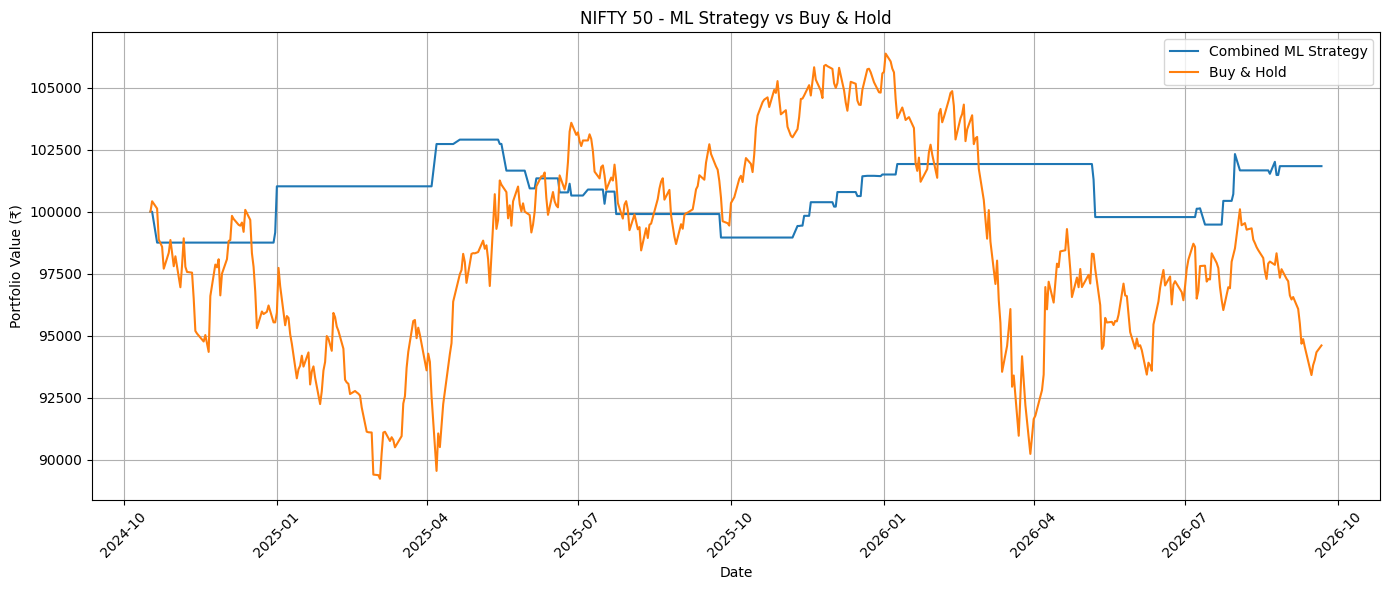

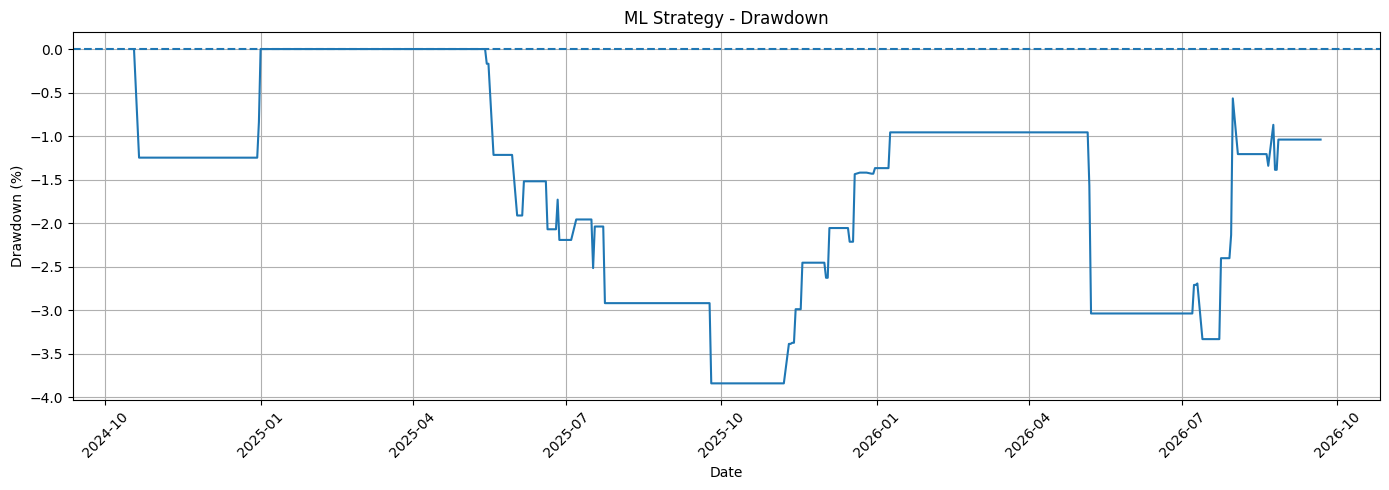

In [50]:
# ============================================================
# EQUITY CURVE + BUY & HOLD + MAX DRAWDOWN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Work on test period only
equity_df = combined_df.iloc[split_index:].copy().reset_index(drop=True)

# Initial capital
initial_capital = 100000

# ------------------------------------------------------------
# 1. Strategy Daily Return
# ------------------------------------------------------------
# UP signal -> hold for next trading day
# Otherwise -> cash

equity_df["Strategy_Return"] = np.where(
    equity_df["Combined_Signal"] == "UP",
    equity_df["Return_1D"] / 100,
    0
)

# Remove final row because next-day return is unavailable
equity_df = equity_df.dropna(
    subset=["Strategy_Return"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Strategy Equity
# ------------------------------------------------------------

equity_df["Strategy_Equity"] = (
    initial_capital *
    (1 + equity_df["Strategy_Return"]).cumprod()
)

# ------------------------------------------------------------
# 3. Buy & Hold
# ------------------------------------------------------------

first_close = equity_df["Close"].iloc[0]

equity_df["BuyHold_Equity"] = (
    initial_capital *
    equity_df["Close"] / first_close
)

# ------------------------------------------------------------
# 4. Drawdown
# ------------------------------------------------------------

equity_df["Strategy_Peak"] = (
    equity_df["Strategy_Equity"].cummax()
)

equity_df["Strategy_Drawdown"] = (
    equity_df["Strategy_Equity"]
    / equity_df["Strategy_Peak"] - 1
) * 100

max_drawdown = equity_df["Strategy_Drawdown"].min()

# ------------------------------------------------------------
# 5. Final Results
# ------------------------------------------------------------

final_strategy = equity_df["Strategy_Equity"].iloc[-1]
final_buyhold = equity_df["BuyHold_Equity"].iloc[-1]

strategy_return = (
    final_strategy / initial_capital - 1
) * 100

buyhold_return = (
    final_buyhold / initial_capital - 1
) * 100

print("==============================================")
print("EQUITY CURVE BACKTEST")
print("==============================================")

print(f"Initial Capital       : ₹{initial_capital:,.2f}")
print(f"Final Strategy Value  : ₹{final_strategy:,.2f}")
print(f"Strategy Return       : {strategy_return:.2f}%")
print(f"Final Buy & Hold      : ₹{final_buyhold:,.2f}")
print(f"Buy & Hold Return     : {buyhold_return:.2f}%")
print(f"Maximum Drawdown      : {max_drawdown:.2f}%")

# ------------------------------------------------------------
# 6. Number of UP Signals
# ------------------------------------------------------------

up_signals = (
    equity_df["Combined_Signal"] == "UP"
).sum()

print(f"UP Signals            : {up_signals}")


# ------------------------------------------------------------
# 7. Equity Curve Chart
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    equity_df["Date"],
    equity_df["Strategy_Equity"],
    label="Combined ML Strategy"
)

plt.plot(
    equity_df["Date"],
    equity_df["BuyHold_Equity"],
    label="Buy & Hold"
)

plt.title("NIFTY 50 - ML Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Drawdown Chart
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    equity_df["Date"],
    equity_df["Strategy_Drawdown"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("ML Strategy - Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# Save Combined Signal Data
combined_path = (
    "/content/drive/MyDrive/"
    "Share_Market_ML_Project/results/"
    "Combined_Signal_Analysis.csv"
)

combined_df.to_csv(combined_path, index=False)


# Save Backtest Results
backtest_path = (
    "/content/drive/MyDrive/"
    "Share_Market_ML_Project/results/"
    "Combined_Signal_Backtest.csv"
)

backtest_df.to_csv(backtest_path, index=False)


# Save Equity Curve Data
equity_path = (
    "/content/drive/MyDrive/"
    "Share_Market_ML_Project/results/"
    "Equity_Curve_Backtest.csv"
)

equity_df.to_csv(equity_path, index=False)


print("✅ Files saved successfully")
print(combined_path)
print(backtest_path)
print(equity_path)

✅ Files saved successfully
/content/drive/MyDrive/Share_Market_ML_Project/results/Combined_Signal_Analysis.csv
/content/drive/MyDrive/Share_Market_ML_Project/results/Combined_Signal_Backtest.csv
/content/drive/MyDrive/Share_Market_ML_Project/results/Equity_Curve_Backtest.csv


In [52]:
# ============================================================
# MODEL COMPARISON
# ============================================================

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Naive Bayes",
        "CART",
        "KNN"
    ],
    "Accuracy_%": [
        49.90,
        51.88,
        48.12,
        47.70
    ],
    "Macro_Precision_%": [
        33.71,
        34.96,
        36.58,
        35.80
    ],
    "Macro_Recall_%": [
        35.95,
        34.91,
        37.75,
        35.38
    ],
    "Macro_F1_%": [
        31.75,
        29.27,
        34.93,
        33.41
    ]
})

print("==============================================")
print("ML MODEL COMPARISON")
print("==============================================")

display(model_comparison)

ML MODEL COMPARISON


,Model,Accuracy_%,Macro_Precision_%,Macro_Recall_%,Macro_F1_%
0,Random Forest,49.90,33.71,35.95,31.75
1,Naive Bayes,51.88,34.96,34.91,29.27
2,CART,48.12,36.58,37.75,34.93
3,KNN,47.70,35.80,35.38,33.41


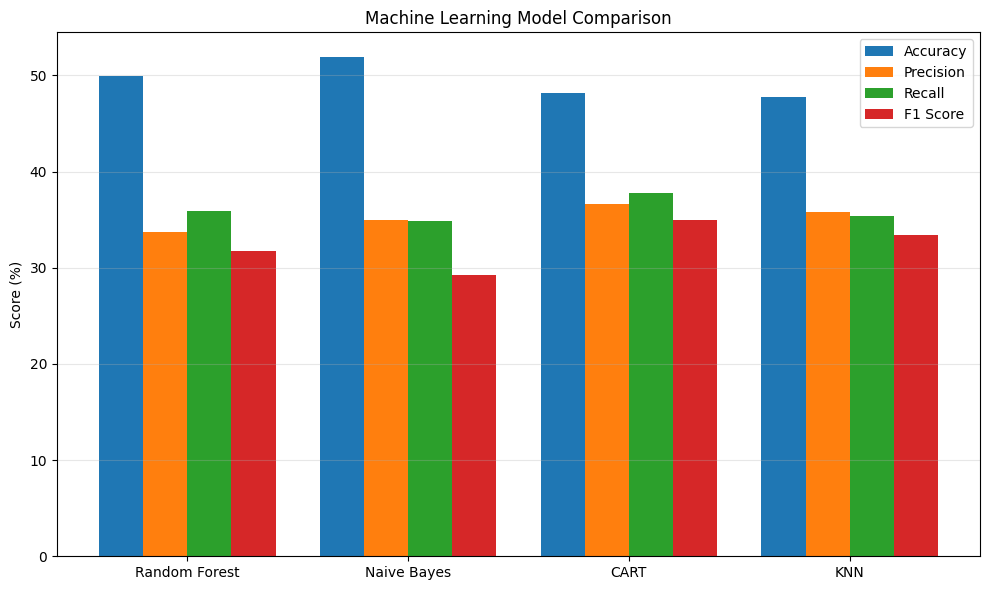

In [53]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x = range(len(model_comparison))

plt.bar(
    [i - 0.3 for i in x],
    model_comparison["Accuracy_%"],
    width=0.2,
    label="Accuracy"
)

plt.bar(
    [i - 0.1 for i in x],
    model_comparison["Macro_Precision_%"],
    width=0.2,
    label="Precision"
)

plt.bar(
    [i + 0.1 for i in x],
    model_comparison["Macro_Recall_%"],
    width=0.2,
    label="Recall"
)

plt.bar(
    [i + 0.3 for i in x],
    model_comparison["Macro_F1_%"],
    width=0.2,
    label="F1 Score"
)

plt.xticks(
    list(x),
    model_comparison["Model"]
)

plt.ylabel("Score (%)")
plt.title("Machine Learning Model Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
comparison_path = (
    "/content/drive/MyDrive/"
    "Share_Market_ML_Project/results/"
    "ML_Model_Comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

print("✅ Model comparison saved:")
print(comparison_path)

✅ Model comparison saved:
/content/drive/MyDrive/Share_Market_ML_Project/results/ML_Model_Comparison.csv


RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance,Importance_%
0,Volatility_20,0.136531,13.65
1,RSI_14,0.131958,13.20
2,Daily_Return,0.127199,12.72
3,MACD,0.125208,12.52
4,Price_Change,0.125204,12.52
5,Volume_Change,0.121593,12.16
6,SMA_20,0.116775,11.68
7,SMA_50,0.115531,11.55


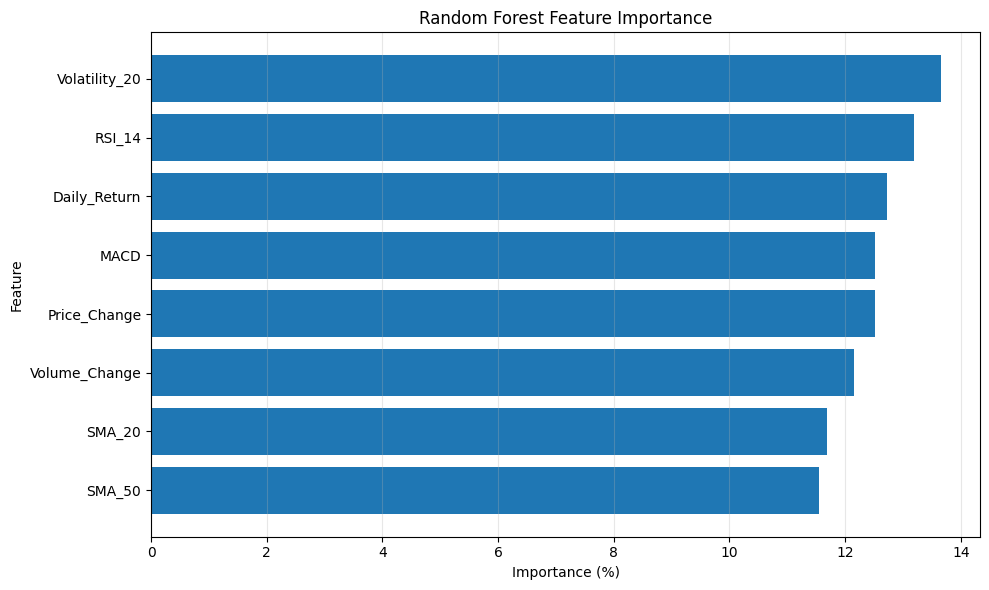

✅ Feature importance saved:
/content/drive/MyDrive/Share_Market_ML_Project/results/RandomForest_Feature_Importance.csv


In [55]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Features used by Random Forest
features = [
    "Daily_Return",
    "Price_Change",
    "SMA_20",
    "SMA_50",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "Volatility_20"
]

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Percentage
feature_importance["Importance_%"] = (
    feature_importance["Importance"] * 100
).round(2)

print("==============================================")
print("RANDOM FOREST FEATURE IMPORTANCE")
print("==============================================")

display(feature_importance)


# ============================================================
# CHART
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance_%"]
)

plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# SAVE
# ============================================================

feature_path = (
    "/content/drive/MyDrive/"
    "Share_Market_ML_Project/results/"
    "RandomForest_Feature_Importance.csv"
)

feature_importance.to_csv(
    feature_path,
    index=False
)

print("✅ Feature importance saved:")
print(feature_path)

In [57]:
# ==========================================
# DEMAND / SUPPLY CANDLE FEATURES
# ==========================================

import numpy as np

df_ds = pattern_df.copy()

# Previous candle values
df_ds["Prev_Open"] = df_ds["Open"].shift(1)
df_ds["Prev_Close"] = df_ds["Close"].shift(1)
df_ds["Prev_High"] = df_ds["High"].shift(1)
df_ds["Prev_Low"] = df_ds["Low"].shift(1)

# Candle direction
df_ds["Candle_Type"] = np.where(
    df_ds["Close"] > df_ds["Open"],
    "GREEN",
    np.where(
        df_ds["Close"] < df_ds["Open"],
        "RED",
        "DOJI"
    )
)

# Current Open relationship with previous candle
df_ds["Open_Type"] = "EQUAL"

df_ds.loc[
    df_ds["Open"] > df_ds["Prev_Close"],
    "Open_Type"
] = "ABOVE"

df_ds.loc[
    df_ds["Open"] < df_ds["Prev_Close"],
    "Open_Type"
] = "BELOW"

# Inside previous candle body
prev_body_high = df_ds[["Prev_Open", "Prev_Close"]].max(axis=1)
prev_body_low = df_ds[["Prev_Open", "Prev_Close"]].min(axis=1)

inside_body = (
    (df_ds["Open"] >= prev_body_low) &
    (df_ds["Open"] <= prev_body_high)
)

df_ds.loc[inside_body, "Open_Type"] = "INSIDE"

# Body strength
df_ds["Body"] = (
    df_ds["Close"] - df_ds["Open"]
).abs()

df_ds["Range"] = (
    df_ds["High"] - df_ds["Low"]
)

df_ds["Body_Strength"] = np.where(
    df_ds["Range"] > 0,
    df_ds["Body"] / df_ds["Range"],
    0
)

# Strong / Weak candle
df_ds["Candle_Strength"] = "WEAK"

df_ds.loc[
    df_ds["Body_Strength"] >= 0.60,
    "Candle_Strength"
] = "STRONG"

# Demand / Supply classification
df_ds["Demand_Supply"] = "NEUTRAL"

df_ds.loc[
    (df_ds["Candle_Type"] == "GREEN") &
    (df_ds["Candle_Strength"] == "STRONG"),
    "Demand_Supply"
] = "DEMAND"

df_ds.loc[
    (df_ds["Candle_Type"] == "RED") &
    (df_ds["Candle_Strength"] == "STRONG"),
    "Demand_Supply"
] = "SUPPLY"

display(
    df_ds[
        [
            "Date",
            "Open",
            "High",
            "Low",
            "Close",
            "Candle_Type",
            "Open_Type",
            "Body_Strength",
            "Candle_Strength",
            "Demand_Supply"
        ]
    ].tail(20)
)

,Date,Open,High,Low,Close,Candle_Type,Open_Type,Body_Strength,Candle_Strength,Demand_Supply
2444,2026-08-25,24175.75,24334.55,24115.45,24334.55,GREEN,BELOW,0.724783,STRONG,DEMAND
2445,2026-08-26,24341.95,24378.60,24207.75,24207.75,RED,ABOVE,0.785484,STRONG,SUPPLY
2446,2026-08-27,24277.60,24297.45,24090.85,24090.85,RED,INSIDE,0.903921,STRONG,SUPPLY
2447,2026-08-28,24122.60,24188.30,24076.85,24175.65,GREEN,INSIDE,0.475998,WEAK,NEUTRAL
2448,2026-08-31,24117.55,24128.70,23993.60,24080.40,RED,BELOW,0.274981,WEAK,NEUTRAL
2449,2026-09-01,24077.55,24143.15,23952.55,24055.80,RED,BELOW,0.114113,WEAK,NEUTRAL
2450,2026-09-02,23858.00,23914.45,23786.80,23914.45,GREEN,BELOW,0.442225,WEAK,NEUTRAL
2451,2026-09-03,23997.95,24025.40,23873.45,23873.45,RED,ABOVE,0.819348,STRONG,SUPPLY
2452,2026-09-04,23910.90,24005.75,23895.85,23897.70,RED,INSIDE,0.120109,WEAK,NEUTRAL
2453,2026-09-07,23883.15,23890.00,23737.90,23779.15,RED,BELOW,0.683761,STRONG,SUPPLY


In [58]:
import pandas as pd
import numpy as np

# Load your dataset
# df = pd.read_csv('your_candle_data.csv')

def is_pivot_low(df, i, window=2):
    """Check if candle i is a swing low (Support)"""
    for j in range(i - window, i + window + 1):
        if j < 0 or j >= len(df):
            continue
        if df['Low'].iloc[j] < df['Low'].iloc[i]:
            return False
    return True

def is_pivot_high(df, i, window=2):
    """Check if candle i is a swing high (Resistance)"""
    for j in range(i - window, i + window + 1):
        if j < 0 or j >= len(df):
            continue
        if df['High'].iloc[j] > df['High'].iloc[i]:
            return False
    return True

def detect_sr_levels(df, window=2):
    supports = []
    resistances = []

    for i in range(window, len(df) - window):
        if is_pivot_low(df, i, window):
            supports.append((df['Date'].iloc[i], df['Low'].iloc[i]))
        if is_pivot_high(df, i, window):
            resistances.append((df['Date'].iloc[i], df['High'].iloc[i]))

    return supports, resistances

# Example Usage:
supports, resistances = detect_sr_levels(df, window=2)

print("Detected Support Levels (Date, Price):")
for s in supports:
    print(s)

print("\nDetected Resistance Levels (Date, Price):")
for r in resistances:
    print(r)

Detected Support Levels (Date, Price):
(Timestamp('2016-09-30 00:00:00'), np.float64(8555.2))
(Timestamp('2016-10-17 00:00:00'), np.float64(8506.15))
(Timestamp('2016-10-27 00:00:00'), np.float64(8550.25))
(Timestamp('2016-11-04 00:00:00'), np.float64(8400.25))
(Timestamp('2016-11-09 00:00:00'), np.float64(8002.25))
(Timestamp('2016-11-21 00:00:00'), np.float64(7916.4))
(Timestamp('2016-12-05 00:00:00'), np.float64(8056.85))
(Timestamp('2016-12-26 00:00:00'), np.float64(7893.8))
(Timestamp('2017-01-23 00:00:00'), np.float64(8327.2))
(Timestamp('2017-02-01 00:00:00'), np.float64(8537.5))
(Timestamp('2017-02-08 00:00:00'), np.float64(8715.0))
(Timestamp('2017-02-15 00:00:00'), np.float64(8712.85))
(Timestamp('2017-02-28 00:00:00'), np.float64(8867.6))
(Timestamp('2017-03-03 00:00:00'), np.float64(8860.1))
(Timestamp('2017-03-08 00:00:00'), np.float64(8891.95))
(Timestamp('2017-03-22 00:00:00'), np.float64(9019.3))
(Timestamp('2017-03-27 00:00:00'), np.float64(9024.65))
(Timestamp('2017-0

In [59]:
from sklearn.cluster import KMeans

def get_sr_clusters(df, num_levels=4):
    # Combine Highs and Lows into a single array
    prices = np.array(df['High'].tolist() + df['Low'].tolist()).reshape(-1, 1)

    # Fit KMeans clustering to find price concentration zones
    kmeans = KMeans(n_clusters=num_levels, random_state=42, n_init=10).fit(prices)

    # Extract cluster centers as S&R levels
    sr_levels = sorted([center[0] for center in kmeans.cluster_centers_])

    return sr_levels

# Example Usage:
levels = get_sr_clusters(df, num_levels=5)
print("Auto-Clustered Support & Resistance Levels:")
for lvl in levels:
    print(f"₹{lvl:.2f}")

Auto-Clustered Support & Resistance Levels:
₹9244.62
₹11220.68
₹15413.09
₹18212.71
₹24066.72


In [60]:
def candle_academy_sr_levels(df):
    supports = []
    resistances = []

    for idx, row in df.iterrows():
        # Rule for Strong Support Zone: STRONG DEMAND or INSIDE GREEN
        if row['Demand_Supply'] == 'STRONG DEMAND' or (row['Candle_Type'] == 'GREEN' and row['Open_Type'] == 'INSIDE'):
            supports.append({
                'Date': row['Date'],
                'Level_Type': 'Support (Demand Zone)',
                'Limit_Entry_Open': row['Open'],
                'Safe_SL_Low': row['Low']
            })

        # Rule for Strong Resistance Zone: STRONG SUPPLY or ABOVE RED
        if row['Demand_Supply'] == 'STRONG SUPPLY' or (row['Candle_Type'] == 'RED' and row['Open_Type'] == 'ABOVE'):
            resistances.append({
                'Date': row['Date'],
                'Level_Type': 'Resistance (Supply Zone)',
                'Limit_Entry_Open': row['Open'],
                'Safe_SL_High': row['High']
            })

    return pd.DataFrame(supports), pd.DataFrame(resistances)

# Example Usage with your dataset:
sup_df, res_df = candle_academy_sr_levels(df)

print("=== SUPPORT ZONES ===")
print(sup_df[['Date', 'Limit_Entry_Open', 'Safe_SL_Low']])

print("\n=== RESISTANCE ZONES ===")
print(res_df[['Date', 'Limit_Entry_Open', 'Safe_SL_High']])

KeyError: 'Demand_Supply'

In [61]:
# ============================================================
# PIVOT SUPPORT & RESISTANCE DETECTION
# ============================================================

import numpy as np
import pandas as pd

sr_df = pattern_df.copy().reset_index(drop=True)

window = 2

# Pivot Low = Support
sr_df["Pivot_Low"] = (
    sr_df["Low"]
    .rolling(window=2 * window + 1, center=True)
    .min()
    == sr_df["Low"]
)

# Pivot High = Resistance
sr_df["Pivot_High"] = (
    sr_df["High"]
    .rolling(window=2 * window + 1, center=True)
    .max()
    == sr_df["High"]
)

# Remove edge rows where pivot cannot be confirmed
sr_df.loc[:window-1, "Pivot_Low"] = False
sr_df.loc[:window-1, "Pivot_High"] = False

sr_df.loc[len(sr_df)-window:, "Pivot_Low"] = False
sr_df.loc[len(sr_df)-window:, "Pivot_High"] = False

# Price levels
sr_df["Support_Level"] = np.where(
    sr_df["Pivot_Low"],
    sr_df["Low"],
    np.nan
)

sr_df["Resistance_Level"] = np.where(
    sr_df["Pivot_High"],
    sr_df["High"],
    np.nan
)

print("==========================================")
print("PIVOT SUPPORT / RESISTANCE")
print("==========================================")

print(
    "Support pivots:",
    sr_df["Pivot_Low"].sum()
)

print(
    "Resistance pivots:",
    sr_df["Pivot_High"].sum()
)

print("\nLatest Support Levels:")
display(
    sr_df.loc[
        sr_df["Pivot_Low"],
        ["Date", "Low"]
    ].tail(10)
)

print("\nLatest Resistance Levels:")
display(
    sr_df.loc[
        sr_df["Pivot_High"],
        ["Date", "High"]
    ].tail(10)
)

PIVOT SUPPORT / RESISTANCE
Support pivots: 326
Resistance pivots: 302

Latest Support Levels:


,Date,Low
2389,2026-06-08,23070.15
2392,2026-06-11,23072.05
2400,2026-06-23,23784.95
2404,2026-06-30,23829.20
2410,2026-07-08,23805.20
2422,2026-07-24,23606.30
2435,2026-08-12,24265.95
2440,2026-08-19,24025.65
2450,2026-09-02,23786.80
2459,2026-09-16,23116.10



Latest Resistance Levels:


,Date,High
2381,2026-05-26,24089.80
2388,2026-06-05,23516.35
2397,2026-06-18,24189.25
2402,2026-06-25,24261.60
2409,2026-07-07,24530.90
2413,2026-07-13,24259.80
2417,2026-07-17,24367.30
2428,2026-08-03,24774.30
2445,2026-08-26,24378.60
2458,2026-09-15,23592.85


In [62]:
import pandas as pd

sep_24_data = {
    "Date": "2026-09-24",
    "Open": 23221.80,
    "High": 23281.95,
    "Low": 23046.15,
    "Close": 23063.10,
    "Candle_Type": "RED",
    "Open_Type": "BELOW",
    "Body_Strength": 0.84,
    "Candle_Strength": "STRONG",
    "Demand_Supply": "STRONG SUPPLY"
}

sep_24_df = pd.DataFrame([sep_24_data])

sep_24_df["Date"] = pd.to_datetime(sep_24_df["Date"])

print("24-Sep-2026 candle:")
display(sep_24_df)

24-Sep-2026 candle:


,Date,Open,High,Low,Close,Candle_Type,Open_Type,Body_Strength,Candle_Strength,Demand_Supply
0,2026-09-24,23221.8,23281.95,23046.15,23063.1,RED,BELOW,0.84,STRONG,STRONG SUPPLY


In [63]:
# 25-Sep-2026 final candle
sep_25_data = {
    "Date": "2026-09-25",
    "Open": 0,      # replace
    "High": 0,      # replace
    "Low": 0,       # replace
    "Close": 0      # replace
}

sep_25_df = pd.DataFrame([sep_25_data])
sep_25_df["Date"] = pd.to_datetime(sep_25_df["Date"])

display(sep_25_df)

,Date,Open,High,Low,Close
0,2026-09-25,0,0,0,0


In [64]:
# ============================================================
# S&R FEATURES FOR ML
# ============================================================

ml_sr_df = sr_df.copy()

# Latest confirmed support/resistance carried forward
ml_sr_df["Nearest_Support"] = (
    ml_sr_df["Support_Level"].ffill()
)

ml_sr_df["Nearest_Resistance"] = (
    ml_sr_df["Resistance_Level"].ffill()
)

# Distance from current close
ml_sr_df["Distance_to_Support_%"] = (
    (ml_sr_df["Close"] - ml_sr_df["Nearest_Support"])
    / ml_sr_df["Close"] * 100
)

ml_sr_df["Distance_to_Resistance_%"] = (
    (ml_sr_df["Nearest_Resistance"] - ml_sr_df["Close"])
    / ml_sr_df["Close"] * 100
)

# S/R position
ml_sr_df["SR_Position"] = "MIDDLE"

ml_sr_df.loc[
    ml_sr_df["Distance_to_Support_%"] <= 1,
    "SR_Position"
] = "NEAR_SUPPORT"

ml_sr_df.loc[
    ml_sr_df["Distance_to_Resistance_%"] <= 1,
    "SR_Position"
] = "NEAR_RESISTANCE"

print("==========================================")
print("ML SUPPORT / RESISTANCE FEATURES")
print("==========================================")

display(
    ml_sr_df[
        [
            "Date",
            "Close",
            "Nearest_Support",
            "Nearest_Resistance",
            "Distance_to_Support_%",
            "Distance_to_Resistance_%",
            "SR_Position"
        ]
    ].tail(20)
)

ML SUPPORT / RESISTANCE FEATURES


,Date,Close,Nearest_Support,Nearest_Resistance,Distance_to_Support_%,Distance_to_Resistance_%,SR_Position
2444,2026-08-25,24334.55,24025.65,24774.30,1.269389,1.807101,MIDDLE
2445,2026-08-26,24207.75,24025.65,24378.60,0.752238,0.705766,NEAR_RESISTANCE
2446,2026-08-27,24090.85,24025.65,24378.60,0.270642,1.194437,NEAR_SUPPORT
2447,2026-08-28,24175.65,24025.65,24378.60,0.620459,0.839481,NEAR_RESISTANCE
2448,2026-08-31,24080.40,24025.65,24378.60,0.227363,1.238352,NEAR_SUPPORT
2449,2026-09-01,24055.80,24025.65,24378.60,0.125334,1.341880,NEAR_SUPPORT
2450,2026-09-02,23914.45,23786.80,24378.60,0.533778,1.940877,NEAR_SUPPORT
2451,2026-09-03,23873.45,23786.80,24378.60,0.362956,2.115949,NEAR_SUPPORT
2452,2026-09-04,23897.70,23786.80,24378.60,0.464061,2.012328,NEAR_SUPPORT
2453,2026-09-07,23779.15,23786.80,24378.60,-0.032171,2.520906,NEAR_SUPPORT


In [65]:
# ============================================================
# FINAL CONFIRMATION-SAFE S/R FEATURES
# ============================================================

import numpy as np
import pandas as pd

safe_sr_df = pattern_df.copy().reset_index(drop=True)
safe_sr_df["Date"] = pd.to_datetime(safe_sr_df["Date"])

window = 2

# ------------------------------------------------------------
# Detect pivot candidates
# ------------------------------------------------------------

safe_sr_df["Pivot_Low"] = False
safe_sr_df["Pivot_High"] = False

for i in range(window, len(safe_sr_df) - window):

    current_low = safe_sr_df.loc[i, "Low"]
    current_high = safe_sr_df.loc[i, "High"]

    left_right_lows = safe_sr_df.loc[
        i-window:i+window, "Low"
    ]

    left_right_highs = safe_sr_df.loc[
        i-window:i+window, "High"
    ]

    if current_low == left_right_lows.min():
        safe_sr_df.loc[i, "Pivot_Low"] = True

    if current_high == left_right_highs.max():
        safe_sr_df.loc[i, "Pivot_High"] = True


# ------------------------------------------------------------
# Create confirmed pivot events
# Pivot becomes known AFTER window candles
# ------------------------------------------------------------

support_events = []

resistance_events = []

for i in range(len(safe_sr_df)):

    if safe_sr_df.loc[i, "Pivot_Low"]:

        confirmation_index = i + window

        if confirmation_index < len(safe_sr_df):

            support_events.append({
                "confirm_index": confirmation_index,
                "price": safe_sr_df.loc[i, "Low"]
            })

    if safe_sr_df.loc[i, "Pivot_High"]:

        confirmation_index = i + window

        if confirmation_index < len(safe_sr_df):

            resistance_events.append({
                "confirm_index": confirmation_index,
                "price": safe_sr_df.loc[i, "High"]
            })


# ------------------------------------------------------------
# Find nearest ACTIVE S/R for each candle
# ------------------------------------------------------------

nearest_support = []
nearest_resistance = []

for i in range(len(safe_sr_df)):

    current_price = safe_sr_df.loc[i, "Close"]

    # ----------------------------------------
    # Confirmed supports available by today
    # ----------------------------------------

    available_supports = [
        x["price"]
        for x in support_events
        if x["confirm_index"] < i
        and x["price"] < current_price
    ]

    # ----------------------------------------
    # Confirmed resistances available by today
    # ----------------------------------------

    available_resistances = [
        x["price"]
        for x in resistance_events
        if x["confirm_index"] < i
        and x["price"] > current_price
    ]

    # Nearest support = highest support below price
    if available_supports:
        nearest_support.append(
            max(available_supports)
        )
    else:
        nearest_support.append(np.nan)

    # Nearest resistance = lowest resistance above price
    if available_resistances:
        nearest_resistance.append(
            min(available_resistances)
        )
    else:
        nearest_resistance.append(np.nan)


safe_sr_df["Nearest_Support"] = nearest_support
safe_sr_df["Nearest_Resistance"] = nearest_resistance


# ------------------------------------------------------------
# Distance
# ------------------------------------------------------------

safe_sr_df["Distance_to_Support_%"] = (
    (
        safe_sr_df["Close"]
        - safe_sr_df["Nearest_Support"]
    )
    / safe_sr_df["Close"]
) * 100

safe_sr_df["Distance_to_Resistance_%"] = (
    (
        safe_sr_df["Nearest_Resistance"]
        - safe_sr_df["Close"]
    )
    / safe_sr_df["Close"]
) * 100


# ------------------------------------------------------------
# S/R Position
# ------------------------------------------------------------

safe_sr_df["SR_Position"] = "MIDDLE"

safe_sr_df.loc[
    safe_sr_df["Distance_to_Support_%"].between(0, 1),
    "SR_Position"
] = "NEAR_SUPPORT"

safe_sr_df.loc[
    safe_sr_df["Distance_to_Resistance_%"].between(0, 1),
    "SR_Position"
] = "NEAR_RESISTANCE"


# ------------------------------------------------------------
# Show latest 20
# ------------------------------------------------------------

print("==============================================")
print("FINAL CONFIRMATION-SAFE S/R FEATURES")
print("==============================================")

display(
    safe_sr_df[
        [
            "Date",
            "Close",
            "Nearest_Support",
            "Nearest_Resistance",
            "Distance_to_Support_%",
            "Distance_to_Resistance_%",
            "SR_Position"
        ]
    ].tail(20)
)

FINAL CONFIRMATION-SAFE S/R FEATURES


,Date,Close,Nearest_Support,Nearest_Resistance,Distance_to_Support_%,Distance_to_Resistance_%,SR_Position
2444,2026-08-25,24334.55,24305.40,24334.70,0.119789,0.000616,NEAR_RESISTANCE
2445,2026-08-26,24207.75,24180.80,24226.70,0.111328,0.078281,NEAR_RESISTANCE
2446,2026-08-27,24090.85,24074.20,24189.25,0.069113,0.408454,NEAR_RESISTANCE
2447,2026-08-28,24175.65,24168.85,24189.25,0.028127,0.056255,NEAR_RESISTANCE
2448,2026-08-31,24080.40,24074.20,24089.80,0.025747,0.039036,NEAR_RESISTANCE
2449,2026-09-01,24055.80,24025.65,24089.80,0.125334,0.141338,NEAR_RESISTANCE
2450,2026-09-02,23914.45,23893.70,23938.85,0.086768,0.102030,NEAR_RESISTANCE
2451,2026-09-03,23873.45,23873.35,23938.85,0.000419,0.273944,NEAR_RESISTANCE
2452,2026-09-04,23897.70,23893.70,23938.85,0.016738,0.172192,NEAR_RESISTANCE
2453,2026-09-07,23779.15,23697.80,23807.30,0.342106,0.118381,NEAR_RESISTANCE
